<a href="https://colab.research.google.com/github/ariannab02/Progetto-IntroDSePC-Gruppo-14/blob/Veronica/1_Progetto_IntroDSePC_gruppo_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto del corso - Introduzione alla Data Science e al Pensiero Computazionale - a.a. 2025/2026

# Membri del gruppo 14

Il gruppo 14 è composto da:

*   **Arianna Bertoldo:** matricola 1220440, email arianna.bertoldo@studio.unibo.it
*   **Veronica Contarin:** matricola 1233363, email veronica.contarin@studio.unibo.it


# Materiale del progetto

Il materiale del progetto è il seguente:
* Bank_Marketing.csv: il dataset contiene informazioni raccolte nel corso di attività di telemarketing svolte da un istituto bancario. Ogni record descrive un cliente e l'esito di una campagna di marketing volta a promuovere prodotti di conto deposito. L'obiettivo è quello di costruire modelli predittivi in grado di identificare i clienti che presentano una maggiore probabilità di sottoscrivere il prodotto finanziario offerto.
L'obiettivo della classificazione è prevedere se il cliente sottoscriverà un conto deposito a termine vincolato (variabile y).
* Bank_Marketing_Description: descrizione del dataset e delle variabili.

# Preparazione dell'ambiente

Prima di iniziare questa parte prepariamo l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**.

In [321]:
# Pandas
import pandas as pd
import numpy as np

# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn import svm, tree
from sklearn.metrics import *


# Fase 1

Carichiamo il dataset originale.

In [322]:
bank = pd.read_csv("Bank_Marketing.csv", sep=";")
print (bank)

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

## Input variables - bank client data:
1. **age**  

2. **job**: type of job (admin., blue collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown)
3. **marital**: marital status (married, single, divorced) - note: "divorced" means divorced or widowed
4. **education**: education level (primary, secondary, tertiary, unknown)
5. **default**: has credit in default?
6. **balance**: average yearly balance, in euros
7. **housing**: has housing loan?
8. **loan**: has personal loan?
9. **contact**: contact communication type (unknown, cellular, telephone)
10. **day**: last contact day of the month
11. **month**: last contact month of year
12. **duration**: last contact duration, in seconds
13. **campaign**: number of contacts performed during this campaign and for this client
14. **pdays**: number of days that passed by after the client was last contacted from a previous campaign, -1 means client was not previously contacted
15. **previous**: number of contacts performed before this campaign and for this client
16. **poutcome**: outcome of the previous marketing campaign (failure, success, other, unknown)
  17. **y**: has the client subscribed a term deposit?


## ISTRUZIONI FASE 1

Obiettivo: prima analisi del dataset per comprenderne:
* struttura;
* distribuzioni;
* qualità;
* limiti;
* possibili problemi


Requisiti - almeno:
* 8 domande/ipotesi;
* 5 statistiche descrittive;
* 3 riflessioni critiche sui dati.


Esempi:
* class imbalance;
* outlier;
* feature correlate;
* dati mancanti;
* feature sospette.

## Domanda 1.1

## Come è strutturato il dataset *Bank_Marketing* ?

In [323]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [324]:
print("Le colonne sono:", bank.shape[1])
print("Le righe sono:", bank.shape[0])

Le colonne sono: 17
Le righe sono: 45211


In [325]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [326]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Categorie delle variabili nominali categoriche

In [327]:
for col in bank.select_dtypes(include='object').columns:
    print(col)
    print(bank[col].unique())
    print()

    #stampa le categorie delle variabili categoriche

job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital
['married' 'single' 'divorced']

education
['tertiary' 'secondary' 'unknown' 'primary']

default
['no' 'yes']

housing
['yes' 'no']

loan
['no' 'yes']

contact
['unknown' 'cellular' 'telephone']

month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome
['unknown' 'failure' 'other' 'success']

y
['no' 'yes']



È possibile notare che:
* la variabile '*job*' ha ben 11 varianti (escludendo i valori mancanti '*unknown*')
* la variabile '*poutcome*' (l'effetto della precedente campagna marketing) contiene una variante '*other*' di cui non conosciamo il significato


Convertiamo la variabile 'y' da categorica a numerica, in modo da poterla usare per calcolare la correlazione e il tasso di adozione numericamente.

In [328]:
bank['y_numeric'] = bank['y'].map({'no': 0, 'yes': 1})



---



## Domanda 1.1.2

## Quanti sono i dati mancanti?

In [329]:
print(bank.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
y_numeric    0
dtype: int64


Tramite questa analisi non risultano esserci dati mancanti. Tuttavia, come notato visivamente dalle prime righe del dataset, vi sono dei valori categorizzati come "unknown" e quindi di fatto mancanti.

In [330]:
unknown = (bank == "unknown").sum()

pd.DataFrame({
    "Mancanti": unknown,
    "Percentuale": (unknown / len(bank) * 100).round(1)
})

,Mancanti,Percentuale
age,0,0.0
job,288,0.6
marital,0,0.0
education,1857,4.1
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,13020,28.8
day,0,0.0


In [331]:
bank[bank["contact"] != "unknown"].head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_numeric
12657,27,management,single,secondary,no,35,no,no,cellular,4,jul,255,1,-1,0,unknown,no,0
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,jul,297,1,-1,0,unknown,no,0
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,jul,668,2,-1,0,unknown,no,0
12660,31,technician,single,secondary,no,19,no,no,telephone,4,jul,65,2,-1,0,unknown,no,0
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,jul,436,4,-1,0,unknown,no,0


La variabile '*contact*' assume un valore diverso da '*unknown*' solo a partire dalla riga 12.657, nel mese di luglio.

Notiamo che la maggioranza delle variabili **non** presenta valori mancanti, tuttavia:
* **i dati sui contatti dei clienti sono incompleti**, dal momento che vengono registrati solo a partire dal mese di luglio
* la variabile '*poutcome*', cioè **l'esito della precedente campagna pubblicitaria, è sconosciuto circa nell'80% dei casi**
* istruzione e lavoro presentano basse percentuali di dati mancanti, probabilmente non dichiarati dai clienti stessi

In [332]:
nuovi = (bank['previous'] == 0).sum()
nuovi_perc = (nuovi/len(bank)*100).round(2)
print("I clienti che non erano mai stati contattati prima sono", nuovi,".")
print("L'", nuovi_perc, "%", "del totale.")

I clienti che non erano mai stati contattati prima sono 36954 .
L' 81.74 % del totale.


Le osservazioni mancanti di '*poutcome*' sono quindi prevalentemente riconducibili al fatto che tali clienti non erano stati contattati in precedenza e, di conseguenza, non era disponibile un esito relativo alla campagna di marketing precedente.





---

##Domanda 1.3

##I cliente già contattati compaiono più volte nel dataset?



In [333]:
#idea nostra, codice ai

cols = [
    'age', 'job', 'marital', 'education',
    'default', 'balance', 'housing', 'loan'
]

duplicati = bank[bank.duplicated(subset=cols, keep=False)]
#un duplicato è una riga che ha cols uguali
#mantiene solo le righe duplicate


duplicati.sort_values(cols)
#ordina le colonne di modo che i valori identici
#a partire dalla colonna age siano conseguenti

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_numeric
40887,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes,1
42274,18,student,single,primary,no,608,no,no,cellular,13,nov,210,1,93,1,success,yes,1
40744,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes,1
41487,18,student,single,unknown,no,108,no,no,cellular,8,sep,169,1,-1,0,unknown,yes,1
42954,18,student,single,unknown,no,108,no,no,cellular,9,feb,92,1,183,1,success,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45010,86,retired,married,primary,no,1255,no,no,cellular,14,oct,192,2,92,4,success,no,0
41934,92,retired,married,unknown,no,775,no,no,cellular,22,oct,313,3,-1,0,unknown,yes,1
42727,92,retired,married,unknown,no,775,no,no,cellular,26,jan,164,4,96,3,success,yes,1
44262,93,retired,married,unknown,no,775,no,no,cellular,22,jul,860,2,177,7,success,yes,1


In [334]:
duplicates = bank.duplicated().sum()
print(duplicates)

0


Sì, i clienti contattati più volte compaiono come righe diverse nel dataset:


* tuttavia **non si tratta di duplicati identici**, ma **differiscono** nelle variabili successive a 'duration'
* forniscono informazioni utili e non costituiscono un punto di debolezza del dataset, ma una risorsa informativa aggiuntiva


---

## Domanda 1.4

##Qual è la condizione socio-economica del campione?

In [335]:
(bank['job'].value_counts(normalize=True) * 100).round(2)

,proportion
job,
blue-collar,21.53
management,20.92
technician,16.80
admin.,11.44
services,9.19
retired,5.01
self-employed,3.49
entrepreneur,3.29
unemployed,2.88


In [336]:
bank.groupby('job')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


#named aggregation, richiama le funzioni sotto forma di stringhe

,media,mediana,dev_standard,minimo,massimo
job,,,,,
retired,1984.22,787.0,4397.04,-1598,81204
unknown,1772.36,677.0,2970.29,-295,19706
management,1763.62,572.0,3822.97,-6847,102127
unemployed,1521.75,529.0,3144.67,-1270,44134
self-employed,1647.97,526.0,3684.26,-3313,52587
student,1388.06,502.0,2441.70,-679,24025
technician,1252.63,421.0,2548.54,-2827,45248
housemaid,1392.40,406.0,2984.69,-1941,45141
admin.,1135.84,396.0,2641.96,-1601,64343


Le categorie lavorative più rappresentate, manager e operai, sono, com'è prevedibile, ai poli opposti della distribuzione.

In [337]:
(bank['marital'].value_counts(normalize=True) * 100).round(2)

,proportion
marital,
married,60.19
single,28.29
divorced,11.52


In [338]:
bank.groupby('marital')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


,media,mediana,dev_standard,minimo,massimo
marital,,,,,
married,1425.93,477.0,3140.96,-6847,98417
single,1301.50,437.0,2875.32,-8019,102127
divorced,1178.87,348.0,2926.45,-4057,66721


In [339]:
bank['age_category'] = pd.cut(
    bank['age'],
    bins=[0, 30, 60, float('inf')],
    labels=['Under 30', '30-59', 'Over 60'],
    right=False #nell'intervallo è escluso il valore a destra
)

totali = bank['age_category'].value_counts()
frequenze = ((totali/len(bank))*100).round(2)


pd.DataFrame({
    'totali': totali,
    'percentuali': frequenze
})

,totali,percentuali
age_category,,
30-59,38154,84.39
Under 30,5273,11.66
Over 60,1784,3.95


In [340]:
bank.groupby('age_category')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


/tmp/ipykernel_543/3431944438.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bank.groupby('age_category')['balance'].agg(


,media,mediana,dev_standard,minimo,massimo
age_category,,,,,
Over 60,2458.62,1058.0,5071.70,-4057,81204
30-59,1362.93,449.5,3010.89,-6847,102127
Under 30,986.57,339.0,2155.62,-8019,36252


Notiamo che:
* le **categorie lavorative** più rappresentate sono gli *operai* (21,5%), i *manager* (20,9%) e i *tecnici* (16%), che insieme costituiscono poco più della metà della clientela totale (del campione)
* la **fascia d'età** più rappresentata è quella *intermedia*: chi ha fra i 30 e i 59 anni compone l'84% del campione. I giovani costituiscono l'11,6% e gli anziani sono fortemente sottorappresentati (3,9%)
* per lo **stato civile**, la maggioranza dei clienti nel campione sono sposati (60%), una buona parte sono single (28%) e il restante divorziati o vedovi (11,5%).

***

Analizzando **la distribuzione della giacenza media annua** (variabile che ci fornisce un'idea della loro condizione economica e predisposizione ad usufruire di servizi bancari) in relazione a queste tre variabili ('*job*', '*age*', '*marital*') notiamo che:

* I **pensionati** costituiscono in media la categoria più "ricca", ma anche la più variabile: è probabile che ci siano molti casi che presentano valori molto più alti della media. Tuttavia sono solo una minima parte del campione, attorno al 5%.
* Anche gli **imprenditori** presentano un'altissima variabilità al loro interno, ma anche loro sono pochi rispetto all'insieme (3,3%)

→ potrebbe essere utile studiarne in seguito la distribuzione, per verificare la presenza di *outlier*

* I più "poveri" sono i **lavoratori nei servizi** (circa il 9% del campione), con un valore mediano della giacenza intorno ai 340 euro, contro i 787 dei pensionati, e con meno variabilità rispetto alla media (poco meno di 1000 euro).

Per ciò che riguarda lo stato civile:

* Tendenzialmente i divorziati sono più poveri (e la minor parte del campione, circa l'11%), mentre gli **sposati** più ricchi (~60% del totale).

Mentre per l'età:

* Gli **over 60** (~4% del campione) presentano la giacenza media più alta fra tutte le categorie considerate (media di 2458 euro annui), ma una fortissima variabilità al suo interno.

* La categoria di mezza età (~84% del totale) si colloca a livello intermedio, fra anziani tendenzialmente molto più "ricchi" e giovani più "poveri".






---

## Domanda 1.5

## Quanti clienti hanno sottoscritto un conto deposito in questa campagna? E quanti hanno avuto un esito positivo nella precedente?

In [341]:
print("Aderenti al conto deposito nella campagna attuale:", round(len(bank[bank["y"] == "yes"]) / len(bank)*100, 2), "%")

Aderenti al conto deposito nella campagna attuale: 11.7 %


In [342]:
print("Aderenti alla campagna precedente sul totale del dataset:", round(len(bank[bank["poutcome"] == "success"]) / len(bank)*100, 2), "%")
print("Aderenti alla campagna precedente tra esiti noti:", round(len(bank[bank["poutcome"] == "success"]) / len(bank[bank["poutcome"] != "unknown"])*100, 2), "%")

Aderenti alla campagna precedente sul totale del dataset: 3.34 %
Aderenti alla campagna precedente tra esiti noti: 18.31 %



Nella campagna attuale, i clienti che hanno sottoscritto il conto deposito rappresentano l'11,7% del totale, quindi circa 1 cliente su 10.

Nella campagna precedente, i casi con esito positivo sono pari al 3,34% del campione complessivo. Tuttavia, escludendo le osservazioni con esito 'unknown', riconducibili a clienti non contattati in precedenza, il tasso di successo tra i soli casi con esito noto sale al 18,31%.
Questo valore risulta quindi superiore di 6.5 punti percentuali a quello della campagna attuale.

---

## Domanda 1.6

## La condizione socio-economica ha influenzato l'adesione ad un conto deposito?

In [343]:
ct = pd.crosstab(index = bank['job'], columns = bank['y'], normalize = "index").round(3)*100
ct_job = ct.sort_values(by='yes', ascending=False)
ct_job

y,no,yes
job,,
student,71.3,28.7
retired,77.2,22.8
unemployed,84.5,15.5
management,86.2,13.8
admin.,87.8,12.2
unknown,88.2,11.8
self-employed,88.2,11.8
technician,88.9,11.1
services,91.1,8.9


* Gli **studenti** sono stati i più propensi ad iscriversi ad un conto deposito (quasi il 29% lo è); seguono pensionati, disoccupati, manager e amministrativi.

* I meno inclini in assoluto sono stati gli **operai** (il 7%), seguiti da imprenditori, casalinghi e lavoratori nei servizi.




In [344]:
ct = pd.crosstab(index = bank['marital'], columns = bank['y'], normalize = "index").round(3)*100
ct_marital = ct.sort_values(by='yes', ascending=False)
ct_marital

y,no,yes
marital,,
single,85.1,14.9
divorced,88.1,11.9
married,89.9,10.1


* Le differenze fra gruppi sono di pochi punti percentuale (al massimo 5%), comunque sembra che i **single** siano stati i più inclini ad aprire un conto deposito, mentre gli **sposati** i meno.

In [345]:
ct = pd.crosstab(index = bank['age_category'], columns = bank['y'], normalize = "index").round(3)*100
ct_age = ct.sort_values(by='yes', ascending=False)
ct_age

y,no,yes
age_category,,
Over 60,66.4,33.6
Under 30,82.4,17.6
30-59,90.1,9.9


Qui le differenze sono rilevanti:

* gli **over 60** hanno aperto con molta frequenza un conto deposito (il 33,6% di loro lo ha fatto)
* invece, solo il 10% della fascia di **mezza età** lo ha fatto

---

## Domanda 1.7

## Esiste un'associazione tra l'indebitamento, l'insolvenza e la sottoscrizione del conto deposito?

In [346]:
# @title Relazione tra debiti e insolvenza
round(pd.crosstab(index=[bank["loan"], bank["housing"]], columns = bank["default"], normalize = "index"), 4)*100

default          no   yes
loan housing             
no   no       98.77  1.23
     yes      98.55  1.45
yes  no       94.16  5.84
     yes      96.95  3.05

Si nota una maggiore tendenza all'insolvenza tra i clienti che hanno contratto un prestito personale. Curiosamente, chi ha sia un prestito personale che un mutuo per la casa ha un tasso di indebitamento inferiore a chi ha solo il prestito personale.

In [347]:
# @title Relazione tra debiti e sottoscrizione del conto deposito
round(pd.crosstab(index=[bank["loan"], bank["housing"]], columns = bank["y"], normalize = "index"), 4)*100

y                no    yes
loan housing              
no   no       81.78  18.22
     yes      91.96   8.04
yes  no       92.39   7.61
     yes      93.93   6.07

I clienti che non hanno contratto prestiti di alcun tipo presentano il tasso di adesione più elevato alla campagna (18,22%).   
La probabilità di sottoscrivere il deposito diminuisce sensibilmente, di circa 10 punti percentuali, in presenza di almeno una forma di indebitamento e raggiunge il valore più basso tra i clienti che possiedono contemporaneamente un prestito personale e un mutuo (6,07%). Questo valore è comunque di soli 2 punti percentuali inferiore rispetto a chi ha contratto un unico prestito.

Complessivamente, si evidenzia una associazione negativa tra l'indebitamento del cliente e la probabilità di adesione al conto deposito proposto.

In [348]:
# @title Relazione tra insolvenza e sottoscrizione del conto deposito
round(pd.crosstab(index=[bank["default"]], columns = bank["y"], normalize = "index"), 4)*100

y,no,yes
default,,
no,88.20,11.80
yes,93.62,6.38


I clienti insolventi presentano un tasso di sottoscrizione inferiore rispetto ai clienti non insolventi (6,38% vs 11,80%).
L'insolvenza sembra quindi essere associata a una minore probabilità di aderire al conto deposito.

**Riflessione**


Questi risultati suggeriscono che la condizione finanziaria possa avere un'influenza sulla sottoscrizione del conto deposito.

In particolare, indebitamento e insolvenza paiono associati a una minore propensione alla sottoscrizione, probabilmente perché i clienti con più difficoltà e/o impegni finanziari dispongono di minore liquidità o sono meno inclini a vincolare i loro risparmi per il periodo richiesto dal conto deposito proposto.

Si nota infine che si tratta di una relazione descrittiva e che al momento non possiamo stabilire se indebitamento e insolvenza causino una minore adesione o se ciò sia dato da altri fattori.

---

## Domanda 1.8

## Come sono stati contattati i clienti? C'è una correlazione con l'età?

L'ipotesi da cui partiamo è che le persone più anziane siano state probabilmente contatte più spesso tramite telefono fisso rispetto al cellulare.

In [349]:
# @title Distribuzione dei mezzi di contatto
contact_assoluto = bank['contact'].value_counts()
contact_perc = bank['contact'].value_counts(normalize=bool).round(4)*100

pd.DataFrame({
    'totali': contact_assoluto,
    'percentuali': contact_perc
})

,totali,percentuali
contact,,
cellular,29285,64.77
unknown,13020,28.80
telephone,2906,6.43


Il 64,8% dei clienti è stato contattato tramite cellulare, e solo il 6,4% via telefono fisso. D'altro canto, quasi il 29% delle osservazioni in questo campo è mancante.
La maggior parte dei dati mancanti è riferita ai primi mesi della campagna, da maggio al 7 luglio, periodo nel quale questo dato non è stato raccolto.

In [350]:
# @title Età media per mezzo di contatto
bank.groupby(bank["contact"])["age"].mean()

,age
contact,
cellular,40.400785
telephone,47.837922
unknown,40.600077


L'età media di chi è stato contattato tramite mezzo ignoto corrisponde con l'età media dei clienti nel dataset. Quella del 'cellular' è solo marginalmente sotto alla media. Dall'altro lato, i clienti contattati tramite telefono fisso hanno un età media decisamente più alta della media del dataset.

In [351]:
# @title Distribuzione del mezzo di contatto per classi di età
pd.crosstab(index = bank["age_category"], columns = bank["contact"], normalize = "index").round(4)*100

contact,cellular,telephone,unknown
age_category,,,
Under 30,66.51,4.63,28.86
30-59,64.55,5.81,29.64
Over 60,64.35,24.94,10.71


L'ipotesi è confermata. I clienti più anziani (Over 60) sono stati contattati via telefono fisso (telephone) con una frequenza significativamente maggiore (24.94%) rispetto alle altre fasce d'età. Inoltre, la percentuale di contatti unknown è molto inferiore per gli Over 60 (10.71%). Una possibile spiegazione è che siano stati chiamati soprattutto dopo luglio, quindi una volta iniziato a raccogliere il dato.


In [352]:
unknowncontact = bank[bank["contact"] == "unknown"]
contact_until_july7 = bank.iloc[0:12657]
print("Il", round(len (contact_until_july7) / len(unknowncontact), 4)*100, "% dei contatti mancanti risale al periodo fino al 7 luglio.")

Il 97.21 % dei contatti mancanti risale al periodo fino al 7 luglio.


In [353]:
print("Over 60 totali:", len(bank[bank["age"] >= 60]), f"({round(len(bank[bank["age"] >= 60]) / len(bank)*100, 2)}%)")
print("")
print("Over 60 tra i clienti contattati prima del 7 luglio:", len(contact_until_july7[contact_until_july7["age"] >= 60]), f"({round(len(contact_until_july7[contact_until_july7["age"] >= 60]) / len(contact_until_july7)*100,2)}%)")

Over 60 totali: 1784 (3.95%)

Over 60 tra i clienti contattati prima del 7 luglio: 186 (1.47%)


Poiché circa il 29% delle osservazioni presenta un tipo di contatto unknown, è opportuno verificare se tali valori siano casuali. Il 97,2% di essi è concentrato nei primi mesi della campagna (fino al 7 luglio), suggerendo che l'assenza derivi principalmente da una mancata raccolta dell'informazione piuttosto che da caratteristiche dei clienti.
Tuttavia, in quel periodo i clienti con almeno 60 anni risultano sottorappresentati (1,47% contro il 3,95% dell'intero campione).

Questo potrebbe in parte spiegare la minore incidenza di contatti tramite telefono fisso tra i valori unknown.

**Riflessione**

Dall'analisi, si evidenzia che il mezzo di contatto varia con l'età del cliente.
I clienti più anziani vengono raggiunti tramite telefono fisso con una frequenza molto più alta rispetto alle altre fasce d'età, che vengono invece principalmente contattate tramite cellulare.

Questa variabile presenta però un problema di fondo, che non ci permette di assegnare elevata significatività ai risultati. Difatti, una quota rilevante (quasi 29%) dei valori è mancante ed è concentrata nei primi mesi della campagna. In quel periodo, gli over 60 risultano sottorappresentati.


Nel complesso, emerge quindi un'associazione plausibile tra età e modalità di contatto, ma per interpretare questa relazione dobbiamo tenere in considerazione l'organizzazione temporale della campagna.

---

## Domanda 1.9

## Esiste un'associazione tra livello di istruzione, insolvenza e sottoscrizione del conto deposito?
L'ipotesi di partenza è che il livello di istruzione possa essere associato sia alla condizione finanziaria del cliente sia alla sua propensione ad aderire alla campagna. In particolare, ci si potrebbe aspettare che clienti con istruzione più elevata abbiano una situazione economica più stabile e che possano avere aggiore familiarità con prodotti bancari e di risparmio, e che siano quindi meno esposti all'insolvenza e più propensi a sottoscrivere un conto deposito.

In [354]:
# @title Relazione tra istruzione e insolvenza
round(pd.crosstab(index= bank["education"], columns = bank["default"], normalize = "index"), 4)*100

default,no,yes
education,,
primary,98.15,1.85
secondary,98.03,1.97
tertiary,98.51,1.49
unknown,98.28,1.72


Non emerge una relazione significativa tra il livello di istruzione e l'insolvenza.

In [355]:
# @title Relazione tra istruzione e sottoscrizione del conto deposito
round(pd.crosstab(index= bank["education"], columns = bank["y"], normalize = "index"), 4)*100

y,no,yes
education,,
primary,91.37,8.63
secondary,89.44,10.56
tertiary,84.99,15.01
unknown,86.43,13.57


Qui emerge un'associazione più evidente. I clienti con istruzione terziaria presentano un tasso di sottoscrizione più elevato, pari al 15,01%, mentre quelli con istruzione primaria mostrano il tasso di adesione più basso, pari all'8,63%.

In definitiva, il livello di istruzione potrebbe essere rilevante nel spiegare la propensione alla sottoscrizione, mentre l'insolvenza non pare utile a ciò.


---

## Domanda 1.10

## I contatti e l'esito della campagna precedente influenzano il successo della campagna attuale?

In [356]:
# @title Relazione tra esito nella campagna precedente e in quella attuale
poutcome_vs_y = pd.crosstab(bank["poutcome"], bank["y"], normalize="index").mul(100).round(2) #mul = multiplication
display(poutcome_vs_y)

y,no,yes
poutcome,,
failure,87.39,12.61
other,83.32,16.68
success,35.27,64.73
unknown,90.84,9.16



Analizzando la relazione tra **esito della campagna precedente** e **apertura di un conto deposito** emerge che:

* i clienti che hanno risposto positivamente alla campagna precedente hanno sottoscritto più spesso un conto deposito (quasi il **65%**)
* quando invece la campagna precedente è risultata fallimentare, spesso nemmeno quella attuale per i conti deposito ha avuto successo (l'87% dei clienti non ha aperto un conto deposito in seguito)
* invece 'failure' e 'unknown' hanno percentuali di successo basse, vicine alla media generale di 11.7%

Una risposta positiva nella campagna passata pare quindi un forte indicatore di una successiva nuova sottoscrizione.

In [357]:
# @title Esiti della campagna attuale per clienti già contattati e non
pd.crosstab(
    bank['previous'] == 0,
    bank['y'],
    normalize='index'
).round(3) * 100

y,no,yes
previous,,
False,76.9,23.1
True,90.8,9.2


I clienti che non erano mai stati contattati prima sono molto restii ad aderire al conto deposito offerto (**solo il 9,2% vi ha aderito**).
I clienti già contattati in altre campagne, invece, sono più propensi ad aprirne uno (il 23% di loro lo ha fatto).


In [358]:
# @title Esiti della campagna precedente per clienti già contattati
pd.crosstab(
    bank['previous'] > 0,
    bank['poutcome'],
    normalize='index'
).round(3) * 100

poutcome,failure,other,success,unknown
previous,,,,
False,0.0,0.0,0.0,100.0
True,59.4,22.3,18.3,0.1


Gli **esiti delle campagne marketing precedenti** hanno, nel complesso, avuto un tasso di insuccesso quasi del 60%.

Non sapendo a cosa si riferisca la categoria 'other', consideriamo un tasso di successo del 18%.


In [359]:
# @title Influenza del numero di contatti precedenti nell'esito della campagna attuale

bank["previous_group"] = pd.cut(
    bank["previous"],
    bins=[-1, 0, 1, 3, 6, 9, 12, 14, 17, bank["previous"].max()],
    labels=["0", "1", "2-3", "4-6", "7-9", "10-12", "12-14", "15-17", "18+"]
)

previous_group_vs_y = pd.crosstab(
    bank["previous_group"],
    bank["y"],
    normalize="index"
).mul(100).round(2)

display(previous_group_vs_y)

y,no,yes
previous_group,,
0,90.84,9.16
1,78.97,21.03
2-3,76.91,23.09
4-6,74.14,25.86
7-9,72.54,27.46
10-12,71.02,28.98
12-14,75.44,24.56
15-17,91.67,8.33
18+,86.25,13.75


I clienti già contattati in passato mostrano tassi di adesione più elevati rispetto a chi non era mai stato chiamato.

In particolare un numero entro i 10-15 contatti precedenti sembra essere associato con una maggiore probabilità di successo rispetto a contatti più numerosi in passato.

Va notato che oltre i 14 contatti, i clienti che sottoscrivono il conto deposito sono sparuti. Da un lato, sono una minoranza i clienti che vengono contattati così tante volte. Dall'altro, ciò potrebbe suggerire un effetto di 'stanchezza' e persistente disinteresse da parte di quei clienti erano già poco interessati.

Un'ipotesi legata all'importanza del successo precedente è che i clienti mai contattati in precedenza sono nuovi clienti con un grado di fidelizzazione e fiducia nell'ente ancora basso. Si potrebbe anche trattare di clienti molto giovani, che hanno appena aperto il loro primo conto in banca, che non hanno ancora una somma di risparmi tale da rendere ragionevole l'adesione a un conto deposito.

In [360]:
# @title Influenza del numero di contatti nell'esito della campagna attuale
bank["campaign_group"] = pd.cut(
    bank["campaign"],
    bins=[0, 1, 2, 3, 5, 10, bank["campaign"].max()],
    labels=["1", "2", "3", "4-5", "6-10", "11+"]
)

campaign_group_vs_y = pd.crosstab(
    bank["campaign_group"],
    bank["y"],
    normalize="index"
).mul(100).round(2)

display(campaign_group_vs_y)

y,no,yes
campaign_group,,
1,85.40,14.60
2,88.80,11.20
3,88.81,11.19
4-5,91.37,8.63
6-10,93.48,6.52
11+,96.07,3.93


Nella campagna attuale, la probabilità di successo è massima tra i clienti contattati una sola volta (14.60%) e diminuisce progressivamente all'aumentare del numero di contatti. Per più di 3-4 contatti, la percentuale di successo cala drasticamente e, in molti casi, diventa 0 per un numero elevato di contatti.

Questo non implica necessariamente che chiamare di più riduca il successo. Difatti, è probabile che i clienti più interessati aderiscano subito, mentre quelli contattati più volte siano già meno propensi alla sottoscrizione, perché non interessati o difficili da convincere. Per alcuni il tempo trascorso tra un contatto e l'altro potrebbe agire da stimolo, mentre molti altri potrebbero essere irremovibili.

Complessivamente, il dato suggerisce quindi un rendimento decrescente dei contatti ripetuti all'interno della stessa campagna.

Ricapitolando:

*  Un esito positivo nella campagna precedente aumenta notevolmente la probabilità di una sottoscrizione nella campagna attuale. Allo stesso modo, un numero moderato (da 1 a 14) di precedenti contatti è associato a una probabilità di successo più elevata rispetto ai clienti mai contattati.
* Per entrambe le variabili che misurano il numero di contatti (previous e campaign) si osserva un andamento simile: a probabilità di successo raggiunge un massimo nelle prime interazioni e successivamente tende a diminuire. Un numero elevato di contatti sembra quindi non aumentare, e anzi essere associato a una minore probabilità di sottoscrizione. Dunque un'eccessiva insistenza non risulta particolarmente efficace.

**Riflessione**

Dall'analisi svolta emerge che la risposta positiva a una precedente campagna marketing della banca rappresenta un fattore rilevante per prevedere il successo di quella attuale. I clienti che hanno già aderito a proposte della banca potrebbero infatti riporre una maggiore fiducia nell'istituto e nei servizi offerti.

D'altra parte, come già osservato, il tasso complessivo di adesione all'offerta del conto deposito nel campione è piuttosto contenuto (11,7%). Considerando che la maggioranza dei clienti nel campione non erano mai stati contattati prima (più dell'80%) e visto il loro basso tasso di adesione (poco più del 9%), questo potrebbe spiegare il basso tasso di successo della campagna attuale.

## Domanda 1.11

## Quanto durano mediamente le chiamate? Esiste un'associazione tra la durata della chiamata e l'esito della campagna?

In [361]:
bank["duration"].describe()

,duration
count,45211.000000
mean,258.163080
std,257.527812
min,0.000000
25%,103.000000
50%,180.000000
75%,319.000000
max,4918.000000


La durata media delle chiamate è di 258 secondi (4 minuti e 18 secondi), e la mediana è di 180 secondi (3 minuti). Il fatto che la media sia superiore alla mediana suggerisce una distribuzione asimmetrica a destra, con alcune chiamate molto lunghe che aumentano il valore medio.  

La durata massima, pari a 4918 secondi ossia circa 82 minuti, appare particolarmente alta e irrealistica; potrebbe essere un errore.

In [362]:
# Calculate IQR
Q1 = bank['duration'].quantile(0.25)
Q3 = bank['duration'].quantile(0.75)
IQR = Q3 - Q1
# Filter out outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_bank = bank[(bank['duration'] >= lower_bound) & (bank['duration'] <= upper_bound)]

In [363]:
filtered_bank["duration"].describe()

,duration
count,41976.000000
mean,203.490947
std,140.805074
min,0.000000
25%,98.000000
50%,167.000000
75%,277.000000
max,643.000000


Per verificare quanto le osservazioni estreme influenzino le statistiche descrittive, proviamo a rimuoverli.

Notiamo ora che la durata media scende di quasi un minuto (a 203 secondi; 3 minuti e 23 secondi), mentre la diminuisce di soli 13 secondi (167 secondi; 2 minuti e 47 secondi).

La chiamata con la durata più alta è di 643 secondi, ossia quasi 11 minuti, e risulta realistica.

La riduzione della media conferma che le chiamate molto lunghe incidono sul valore medio, anche se sono una quota ridotta delle osservazioni.

In [364]:
# @title Relazione tra durata delle chiamate ed esito campagna attuale
duration_by_y = bank.groupby('y')['duration'].describe().round(2)
display(duration_by_y)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.18,207.38,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.29,392.53,8.0,244.0,426.0,725.0,3881.0


In [365]:
pearson_y_dur = bank["y_numeric"].corr(bank["duration"], method="pearson")
print("Correlazione di Pearson:", round(pearson_y_dur, 3))

spearman_y_dur = bank["y_numeric"].corr(bank["duration"], method="spearman")
print("Correlazione di Spearman:", round(spearman_y_dur, 3))

Correlazione di Pearson: 0.395
Correlazione di Spearman: 0.342


Sia la correlazione di Pearson (0.395), sia quella di Spearman (0.342), indicano un'associazione positiva moderata tra durata della chiamata e sottoscrizione del conto deposito.



Le chiamate che portano a una sottoscrizione hanno una durata media (537 secondi) e mediana (426 secondi) nettamente superiori rispetto alle chiamate che non hanno successo (221 e 164 secondi rispettivamente).

L'associazione è molto marcata e suggerisce che conversazioni più prolungate siano accompagnate da esiti tendenzialmente più positivi.


In [366]:
# @title Relazione tra fasce di durata e sottoscrizione
bins = [0, 60, 120, 180, 240, 300, 420, 600, 900, float('inf')]
labels = ['0-60s', '61-120s', '121-180s', '181-240s', '241-300s', '301-420s', '421-600s', '601-900s', '>900s']

bank['duration_bin'] = pd.cut(bank['duration'], bins=bins, labels=labels, right=True, include_lowest=True)

duration_bin_success = pd.crosstab(bank['duration_bin'], bank['y'], normalize='index').mul(100).round(2)
display(duration_bin_success)

y,no,yes
duration_bin,,
0-60s,99.81,0.19
61-120s,97.82,2.18
121-180s,94.22,5.78
181-240s,90.34,9.66
241-300s,87.30,12.70
301-420s,84.31,15.69
421-600s,75.80,24.20
601-900s,58.14,41.86
>900s,40.76,59.24


Suddividendo le chiamate in fasce di durata, la relazione appare ancora più evidente.

Le chiamate inferiori al minuto hanno un tasso di successo quasi nullo, pari allo 0,19%, mentre la percentuale di sottoscrizione aumenta progressivamente al crescere della durata.

Superati i 5 minuti (300 secondi), le percentuali di sottoscrizione diventano considerevolmente più alte e, per le chiamate oltre i 15 minuti, raggiungono il 59,24%.


Queste evidenze confermano e rafforzano l'osservazione precedente: chiamate più lunghe sono fortemente associate a sottoscrizioni riuscite.

**Riflessione**

L'associazione tra durata della chiamata ed esito della campagna è molto marcata, ma non va interpretata come una relazione di causa-effetto. È infatti plausibile che siano i clienti già interessati a prolungare la conversazione per chiedere maggiori informazioni, mentre quelli non interessati tendano a concluderla rapidamente.

La durata della chiamata potrebbe quindi soprattutto riflettere il livello di interesse che emerge durante il contatto, più che rappresentare un fattore che determina la sottoscrizione.



---

## Domanda 1.12

## C'è correlazione tra le variabili?

Avendo convertito '*y*' in '*y_numeric*' possiamo calcolare l'indice di correlazione (distinguendo tra Pearson e Spearman) con le variabili numeriche '*duration*', '*pdays*', '*previous*', '*balance*', '*age*', '*day*', '*campaign*'.

In [367]:
corr_pearson = bank.corr(method="pearson", numeric_only=True)["y_numeric"]
corr_spearman = bank.corr(method="spearman", numeric_only=True)["y_numeric"]

corr_table = pd.DataFrame({
    'Pearson': corr_pearson,
    'Spearman': corr_spearman
    }).sort_values(by=['Pearson', 'Spearman'], ascending=False)

print("Coefficienti di correlazione tra variabili numeriche e 'y' convertita:")
display(corr_table)

Coefficienti di correlazione tra variabili numeriche e 'y' convertita:


,Pearson,Spearman
y_numeric,1.000000,1.000000
duration,0.394521,0.342469
pdays,0.103621,0.154055
previous,0.093236,0.169124
balance,0.052838,0.100295
age,0.025155,-0.008750
day,-0.028348,-0.029548
campaign,-0.073172,-0.084054


Pearson (varia da 1 a -1) individua eventuali relazioni lineari:
* **la relazione più significativa è fra '*duration*' e '*y*'** (0,39): vi sarebbe, dunque, una relazione mediamente forte e di segno positivo fra la durata della durata della chiamata e l'iscrizione ad un conto deposito

Risultano poco rilevanti tutte le altre categorie.

Spearman (varia da 1 a -1) invece:

* ha rilevato valori molto simili a Pearson:

fra quelle analizzate '*duration*' resta la variabile più predittiva di '*y*'

* notiamo che, poichè Spearman è più resistente agli outlier, 'balance' (che abbiamo sottolineato essere una variabile poco omogenea) ha un coefficiente che indica una relazione doppiamente più forte con 'y' rispetto a quanto rilevato con Pearson

* notiamo inoltre che nel caso di 'age' Spearman rileva una relazione negativa, piuttosto che positiva

Curiosità: se la correlazione di Pearson è calcolata su variabili dicotomiche, essa viene chiamata correlazione punto-biseriale.


**CONCLUSIONE**

Il calcolo dei coefficienti di correlazione è utile ma non è stato il nostro punto di partenza, questo perché:

* le variabili categoriche costituiscono la maggioranza delle colonne del dataset

* si è tentato di indagare autonomamente l'impatto delle variabili su 'y', per poi verificare se quanto appreso potesse venire confermato dallo studio della correlazione

A questo punto dell'analisi ipotizziamo, ragionevolmente, che:

* **la durata delle chiamate abbia un notevole impatto sull'iscrizione ad un conto deposito** per i clienti della banca. Come abbiamo visto, al crescere della durata aumentano le percentuali di clienti iscritti: **chiamate più lunghe indicano un interesse manifesto da parte del cliente**, che conversa con l'operatore e indaga sull'offerta che gli viene proposta.

Tuttavia altre ipotesi non verrebbero confermate dall'analisi della correlazione:

* l'età dei clienti, il loro saldo, l'essere già stati contattati non sembrerebbero particolarmente rilevanti, nonostante le nostre analisi indichino il contrario

In ogni caso si tratta ancora di ipotesi, che indagheremo meglio nelle fasi successive.


# Fase 2

Obiettivo: capire (e comunicare) relazioni tra feature - fra di loro, ed in particolare rispetto al target.

Requisiti - almeno:
* 4 grafici diversi;
* 4 domande/ipotesi;
* 2 confronti tra variabili/gruppi/classi.

Cercate di usare gli strumenti che abbiamo affrontato (scatterplot, boxplot,
heatmap, barplot, ecc.).

Opzionalmente: guardate le gallerie di grafici forniti dalla libreria seaborn (es. [1]) e valutate di introdurre alcuni di questi se utile.
[1]
https://seaborn.pydata.org/examples/index.html


## Domanda 2.1

## Quali categorie (lavorative) sono più propense ad aprire un conto deposito?

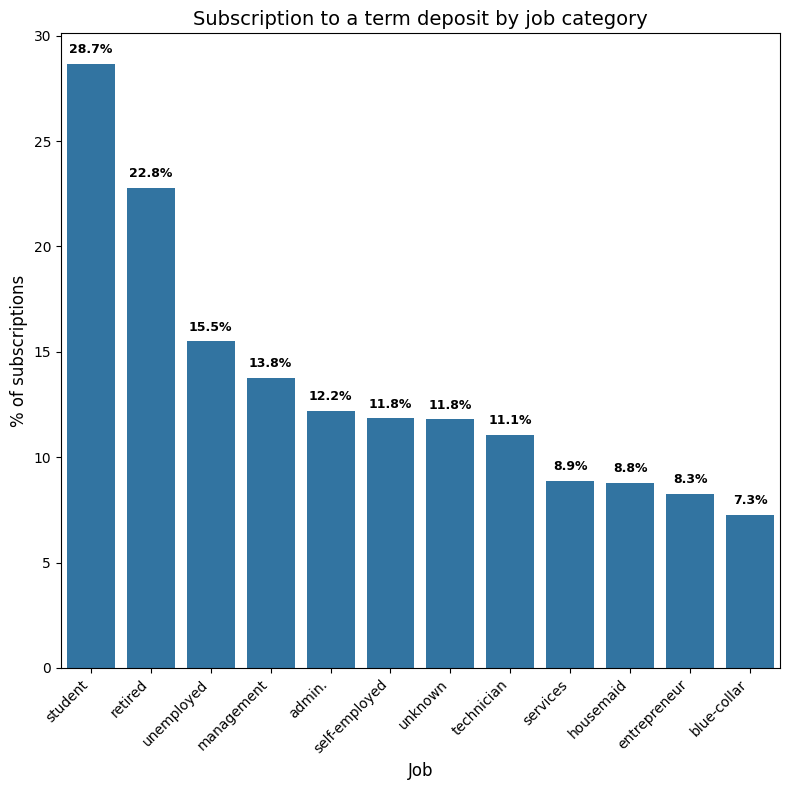

In [368]:
propensione_lavori = (bank.groupby('job')['y']
                      .apply(lambda x: (x == 'yes').mean() * 100)
                      .sort_values(ascending=False))

plt.figure(figsize=(8, 8))

sns.barplot(
    x=propensione_lavori.index,
    y=propensione_lavori.values,
)
for i, v in enumerate(propensione_lavori.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)

plt.title("Subscription to a term deposit by job category", fontsize=14)
plt.xlabel("Job", fontsize=12)
plt.ylabel("% of subscriptions", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Possiamo ipotizzare che le ragione per cui queste particolari categorie lavorative siano più disposte ad aprire un conto deposito siano:



>* **maggiore istruzione** (educazione finanziaria)
>* **maggiore disponibilità economica** (saldo)
>* **propensione al risparmio**

Proviamo a testare le prime due, non avendo indicatori utili per la terza.

/tmp/ipykernel_543/817931034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bank,
/tmp/ipykernel_543/817931034.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8,


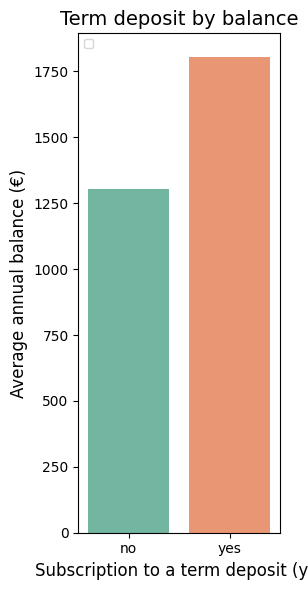

In [369]:
# @title Sottoscrizione a conto deposito (y) in base alla giacenza media
plt.figure(figsize=(3,6))
sns.barplot(data=bank,
            x='y',
            y='balance',
            palette='Set2',
            errorbar=None)

plt.title("Term deposit by balance", fontsize=14)
plt.xlabel('Subscription to a term deposit (y)?', fontsize=12)
plt.ylabel('Average annual balance (€)', fontsize=12)
plt.legend(fontsize=8,
           loc='upper left')

plt.tight_layout()
plt.show()

In effetti chi sottoscrive un conto deposito ha tendenzialmente una giacenza media annua più alta (circa 500 euro di differenza).

Proviamo a visualizzare la distribuzione della giacenza media in base alle classi lavorative.

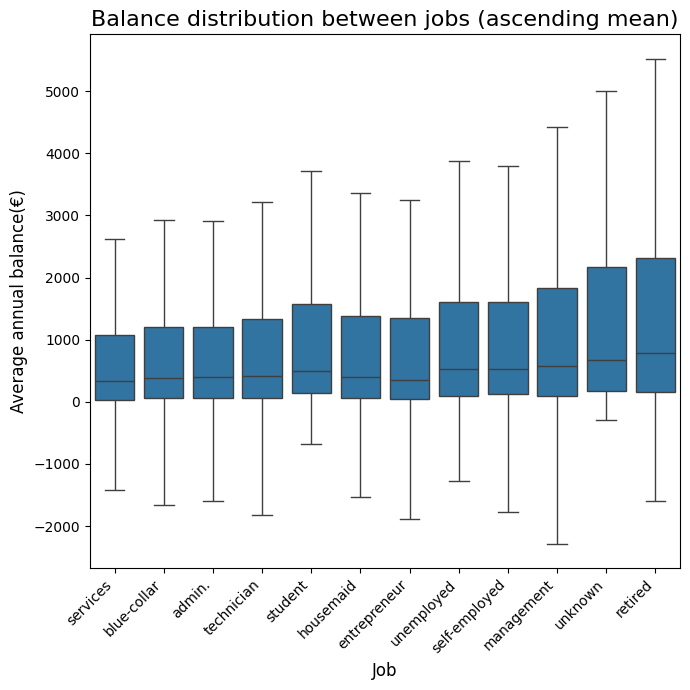

In [370]:
ordine_lavori = bank.groupby('job')['balance'].mean().sort_values().index

plt.figure(figsize=(7, 7))
sns.boxplot(data=bank,
            x='job',
            y='balance',
            order=ordine_lavori,
            showfliers=False),
#plt.ylim(-2000, 10000) #per migliorare la visualizzazione, soglie limite
plt.title("Balance distribution between jobs (ascending mean)", fontsize=16)
plt.xlabel("Job", fontsize=12)
plt.ylabel("Average annual balance(€)", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Quasi tutte le categorie presentano valori del saldo molto variabili** (evidenziato dalla lunghezza dei baffi e dall'altezza del box):

I **manager** hanno i valori minimi e massimi del saldo più distanti nel campione, evidenziando la presenza di picchi sia molto positivi che molto negativi.

I **pensionati** presentano una giacenza in media più alta e con picchi superiori a qualsiasi altra classe.

Gli **studenti** sono la categoria meno in negativo (esclusi gli unknown).

Coloro che lavorano nei **servizi**, sono **operai** oppure lavorano in un ruolo **amministrativo**, presentano invece saldi meno variabili e meno ingenti.




Data l'alta variabilità della variabile 'balance' confrontiamo la distribuzione dei valori secondo la media con la ***mediana***.

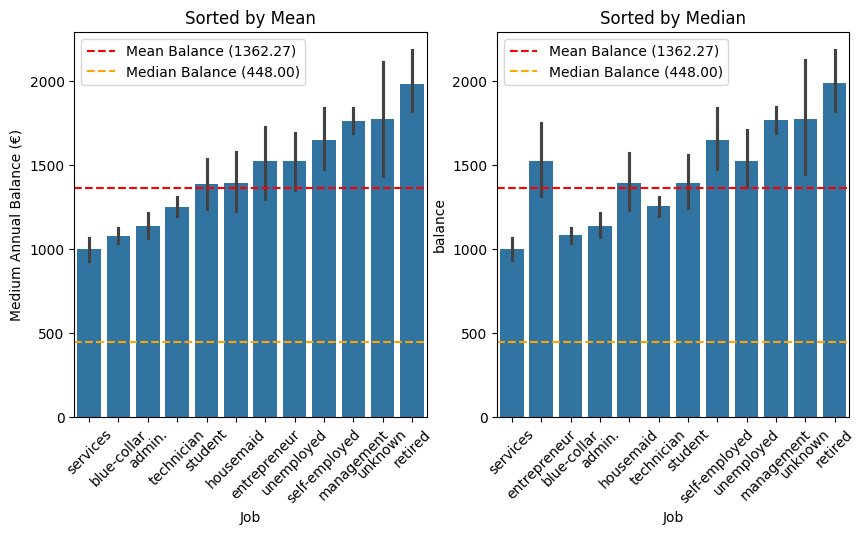

media giacenza nel campione 1362.27
mediana 448.0


,count,mean,std,min,25%,50%,75%,max
job,,,,,,,,
admin.,5171.0,1135.84,2641.96,-1601.0,63.00,396.0,1203.00,64343.0
blue-collar,9732.0,1078.83,2240.52,-8019.0,55.00,388.0,1203.00,66653.0
entrepreneur,1487.0,1521.47,4153.44,-2082.0,44.50,352.0,1341.00,59649.0
housemaid,1240.0,1392.40,2984.69,-1941.0,57.75,406.0,1382.75,45141.0
management,9458.0,1763.62,3822.97,-6847.0,98.00,572.0,1825.00,102127.0
retired,2264.0,1984.22,4397.04,-1598.0,164.50,787.0,2309.00,81204.0
self-employed,1579.0,1647.97,3684.26,-3313.0,120.00,526.0,1603.50,52587.0
services,4154.0,997.09,2164.49,-2122.0,35.00,339.5,1071.75,57435.0
student,938.0,1388.06,2441.70,-679.0,148.25,502.0,1579.75,24025.0


In [371]:
# @title Distribuzione giacenza tra le categorie lavorative
ordine_lavori_media = bank.groupby('job')['balance'].mean().sort_values().index

ordine_lavori_mediana = bank.groupby('job')['balance'].median().sort_values().index

balance_mean = bank['balance'].mean()
balance_median = bank['balance'].median()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=bank, x='job', y='balance',
            order=ordine_lavori_media, ax=axs[0])
axs[0].axhline(balance_mean, color='red', linestyle='--',
               label=f'Mean Balance ({balance_mean:.2f})')
axs[0].axhline(balance_median, color='orange', linestyle='--',
               label=f'Median Balance ({balance_median:.2f})')
axs[0].set_title("Sorted by Mean")
axs[0].set_xlabel("Job")
axs[0].set_ylabel("Medium Annual Balance (€)")
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()


sns.barplot(data=bank, x='job', y='balance',
            order=ordine_lavori_mediana, ax=axs[1])
axs[1].axhline(balance_mean, color='red', linestyle='--',
               label=f'Mean Balance ({balance_mean:.2f})')
axs[1].axhline(balance_median, color='orange', linestyle='--',
               label=f'Median Balance ({balance_median:.2f})')

axs[1].set_title("Sorted by Median")
axs[1].set_xlabel("Job")
axs[1].tick_params(axis='x', rotation=45)
axs[1].legend()

plt.show()

print("media giacenza nel campione", balance_mean.round(2))
print("mediana", balance_median)

bank.groupby('job')['balance'].describe().round(2)

1. Gli **studenti** erano i più propensi ad aprire un conto deposito (28% iscrizione):   
nella distribuzione del saldo medio annuo sono in mezzo, non hanno grandissime somme (valore massimo circa 24mila euro) ma nemmeno conti fortemente in negativo

2. seguivano i **pensionati** (22,8% iscrizione):                          hanno tendenzialmente disponibilità molto maggiori rispetto alla media (con picchi a 80mila euro)

3. al terzo posto i **disoccupati** (15,5% iscrizione):
anche questo gruppo ha una giacenza media nella parte alta della distribuzione

4. al quarto i **manager** (13,8% iscrizione): i manager sono la seconda classe più "ricca" nel campione, tuttavia non mostrano una propensione altrettanto forte per l'iscrizione al conto deposito (probabilmente preferiscono altri strumenti finanziari)

5. infine, al quinto gli **amministrativi** (12,2% iscrizione): questo dato sorprende, dal momento che questa categoria ha una disponibilità economica abbastanza ristretta rispetto ad altre (può essere che il conto deposito sia più congeniale a questa categoria)

**

1. I meno propensi sono stati gli **operai** (7,3%): come osservato, gli operai hanno tendenzialmente saldi più bassi, con una variabilità ridotta rispetto ad altre classi.

2. Anche gli **imprenditori** che hanno aderito al conto deposito sono stati pochi (8,3%): nonostante essi presentino saldi medi più alti, la mediana ha rivelato che la situazione economica reale va tarata al ribasso.

3. Sempre intorno a soglie basse di adesione abbiamo casalinghi (8,8%) e lavoratori nei servizi (8,9%): si tratta di classi lavorative tendenzialmente più "povere".

**

**RIFLESSIONE**

IPOTESI 1 : La disponibilità economica è associata al tasso di iscrizione ad un conto deposito?

Forse.

Le categorie con saldi medi annui più bassi sono effettivamente meno interessate ad aprire un conto deposito (vedi operai).

Le categorie con saldi medi annui più alti sono più iscritte (vedi pensionati), **ma non si tratta di un rapporto causa-effetto**:

Gli studenti, ad esempio, sono fra una delle due classi più risparmiatrici (tanto che difficilmente i loro conti sono in negativo), eppure non hanno un saldo sopra la media.

**


Consideriamo ora il livello di istruzione.

In [372]:
bank["education"].value_counts(normalize=True).round(2)*100

,proportion
education,
secondary,51.0
tertiary,29.0
primary,15.0
unknown,4.0


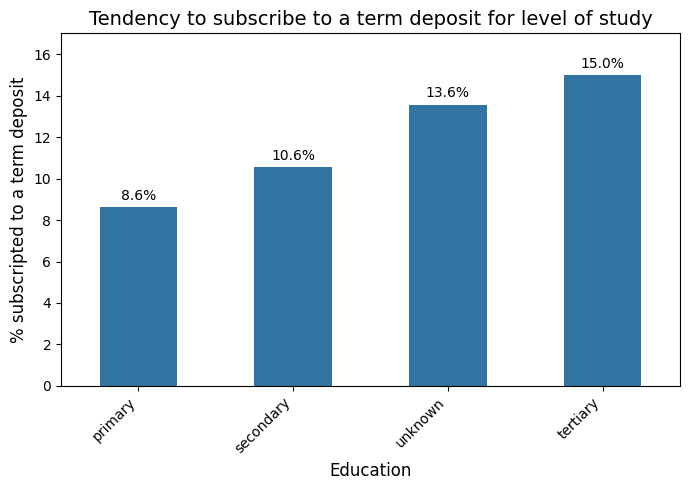

In [373]:
propensione_ed = (bank.groupby('education')['y']
                      .apply(lambda x: (x == 'yes').mean() * 100)
                      .sort_values(ascending=True))

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=propensione_ed.index,
    y=propensione_ed.values,
    width=0.5
)

ax.set_ylim(0, propensione_ed.max() + 2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Tendency to subscribe to a term deposit for level of study", fontsize=14)
plt.xlabel("Education", fontsize=12)
plt.ylabel("% subscripted to a term deposit", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Chi ha un'istruzione superiore tende ad essere più iscritto ad un conto deposito.

Confrontiamo ora fra loro le categorie lavorative.

In [374]:
uno = bank.groupby(bank["job"])["education"]
print((uno.value_counts(normalize=True).round(2)*100).unstack())

education      primary  secondary  tertiary  unknown
job                                                 
admin.             4.0       82.0      11.0      3.0
blue-collar       39.0       55.0       2.0      5.0
entrepreneur      12.0       36.0      46.0      5.0
housemaid         51.0       32.0      14.0      4.0
management         3.0       12.0      82.0      3.0
retired           35.0       43.0      16.0      5.0
self-employed      8.0       37.0      53.0      2.0
services           8.0       83.0       5.0      4.0
student            5.0       54.0      24.0     17.0
technician         2.0       69.0      26.0      3.0
unemployed        20.0       56.0      22.0      2.0
unknown           18.0       25.0      14.0     44.0


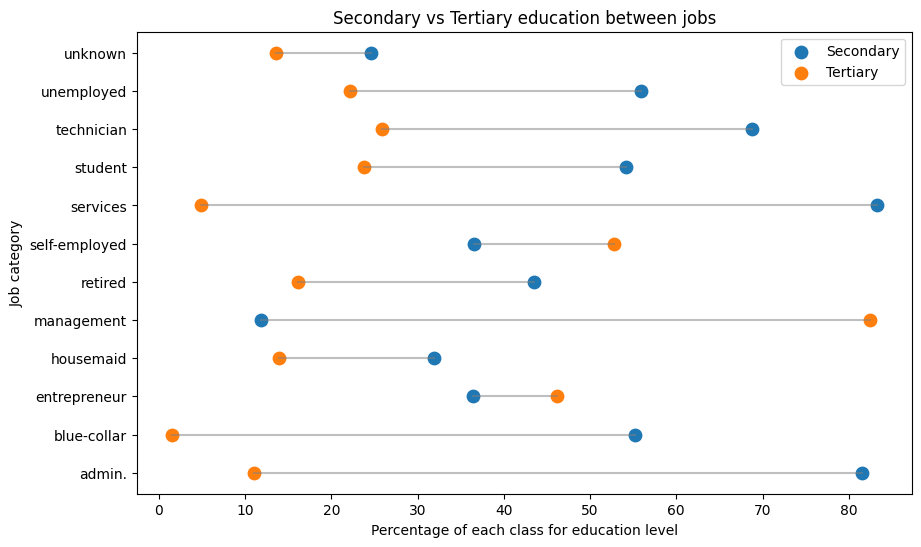

In [375]:
order_by_y = (bank.groupby('job')['y']
                      .apply(lambda x: (x == 'yes').mean() * 100)
                      .sort_values(ascending=False))
uno = bank.groupby(bank["job"])["education"]

edu_dist = (uno.value_counts(normalize=True).unstack()) * 100
edu_dist_for_plot = edu_dist.reset_index()
edu_dist_for_plot['job'] = pd.Categorical(edu_dist_for_plot['job'], categories=order_by_y.index, ordered=True)


plt.figure(figsize=(10,6))

for job in edu_dist.index:
    plt.plot(
        [edu_dist.loc[job, 'secondary'],
         edu_dist.loc[job, 'tertiary']],
        [job, job],
        color='gray',
        alpha=0.5
    )

plt.scatter(
    edu_dist['secondary'],
    edu_dist.index,
    label='Secondary',
    s=80
)

plt.scatter(
    edu_dist['tertiary'],
    edu_dist.index,
    label='Tertiary',
    s=80
)

plt.xlabel('Percentage of each class for education level')
plt.ylabel('Job category')
plt.title('Secondary vs Tertiary education between jobs')
plt.legend()
plt.show()

Il grafico ci mostra la percentuale di istruiti in ciascuna classe lavorativa.

Tra coloro che possiedono un'**istruzione universitaria** o equivalente (il livello più alto nella variabile 'education'):

1.   i **manager** sono i più istruiti, l'82% di loro possiede un'istruzione
2.   i lavoratori autonomi sono i secondi (53%)
3.   gli imprenditori sono la terza categoria più istruita (46%)

**Di questi tre gruppi solo i manager compaiono fra le prime cinque categorie più iscritte ad un conto deposito**.



Tenendo anche conto dell'**istruzione secondaria**:

1. i **lavoratori nei servizi** (83%) e in ruoli **amministrativi** (82%) sono le categorie fortemente istruite (seppur ad un livello secondario), seconde solo ai manager come abbiamo visto nel grafico precedente

2. anche la maggioranza dei tecnici è istruita (69%)

3. disoccupati (56%) e studenti (54%) sono al terzo e al quarto posto


**Di questi solo gli amministrativi sono mediamente più iscritti ad un conto deposito**. Al contrario i lavoratori nei servizi sono uno dei gruppi meno propensi in assoluto.

**

**RIFLESSIONE**

IPOTESI 2: Un livello di istruzione più alto è associato ad un tasso di iscrizione ad un conto deposito?

Probabilmente no.

Considerando che i più propensi ad aprire un conto deposito sono stati studenti, pensionati, disoccupati, manager e amministrativi non notiamo una particolare relazione fra livello di istruzione e tasso di iscrizione.

**Se non fosse così manager, lavoratori autonomi, imprenditori (% istruzione terziaria più alta) e lavoratori nei servizi e tecnici (% istruzione secondaria più alta) sarebbero più propensi ad aprire un conto deposito.**



---
## Domanda 2.2

## Avere debiti influisce sull'iscrizione ad un conto deposito?



In [376]:
(pd.crosstab(bank['loan'], bank['y'], normalize='index')*100).round(2)

y,no,yes
loan,,
no,87.34,12.66
yes,93.32,6.68


Non vi è una differenza così netta nei tassi di iscrizione ad un conto deposito fra chi ha un prestito a carico e chi no.

La maggioranza dei clienti sceglie di non aprire un conto deposito, ma chi ha prestiti è ancora meno propenso.

In [377]:
(pd.crosstab(bank['housing'], bank['y'], normalize='index')*100).round(2)

y,no,yes
housing,,
no,83.3,16.7
yes,92.3,7.7


Avere un mutuo sulla casa è un fattore leggermente più influente sulla scelta di iscriversi ad un conto deposito:

* i clienti iscritti che non hanno un mutuo sono quasi il 17%, contro il 13% di chi è libero da prestiti personali

* tuttavia anche la percentuale di iscritti e con mutuo è leggermente superiore

In [378]:
df_crosstab = pd.crosstab(
    index=[bank['housing'], bank['loan']],
    columns=bank['y'],
    normalize='index'
).round(3) * 100

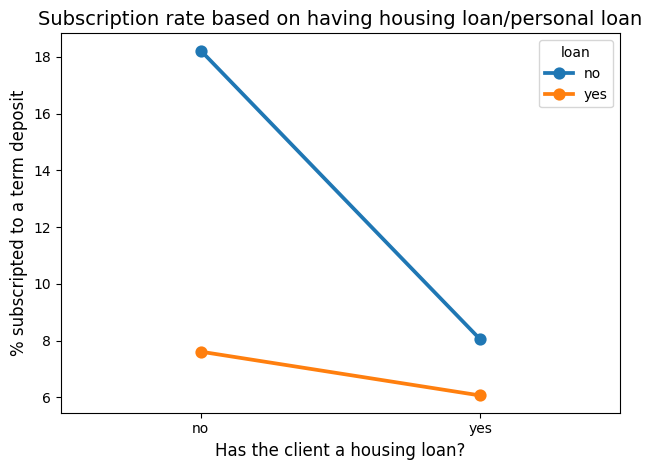

y               no   yes
housing loan            
no      no    81.8  18.2
        yes   92.4   7.6
yes     no    92.0   8.0
        yes   93.9   6.1


In [379]:
#crea dataframe in cui per ogni combinazione housing/loan calcola la % di clienti
#che hanno aderito a conto deposito
prop = (
    bank.groupby(['housing', 'loan'])['y_numeric']
    .mean() * 100
).reset_index(name='Subscription rate')

sns.pointplot(
    data=prop,
    x='housing',
    y='Subscription rate',
    hue='loan'
)

plt.title("Subscription rate based on having housing loan/personal loan", fontsize=14)
plt.xlabel("Has the client a housing loan?", fontsize=12)
plt.ylabel("% subscripted to a term deposit", fontsize=12)

plt.tight_layout()
plt.show()

print(df_crosstab)

* **i clienti senza debiti** sembrano più propensi ad iscriversi ad un conto deposito (**18,2% di iscrizioni**)

* se il cliente ha un debito personale o un mutuo a carico la percentuale scende del 10% (7,6-8% di iscrizioni)

* se il cliente ha sia un mutuo che un debito personale la quota di iscritti ad un conto deposito cala ancora (6,1%)

**Conclusione**

Avere un debito influisce sull'iscrizione ad un conto deposito?

Sì, ma **marginalmente**.

Avere un mutuo o un debito personale fa calare il tasso di iscrizione del 10%, ma questo è basso in partenza (appena il 18%).

La differenza è più netta se il cliente ha sia un prestito personale che un mutuo a carico (in questa casistica il tasso di iscrizione cala del 12%).



## Domanda 2.3
## Come è associato il mezzo di contatto alla probabilità di sottoscrivere il conto deposito tra le varie fasce d'età?

Grafico per giacenza media e tipo di contatto, con la sottoscrizione del conto deposito.

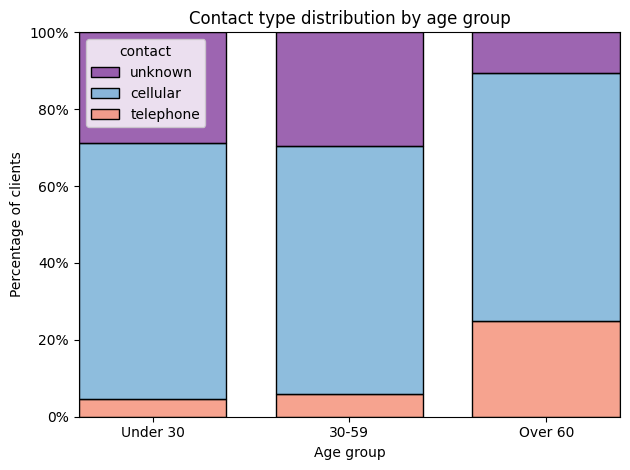

In [380]:
# @title Frequenza nelle fasce d'età dei mezzi di contatto
from matplotlib.ticker import PercentFormatter
age_contact_plot = sns.histplot(x = "age_category", hue = "contact", data = bank,
             multiple = "fill", shrink = 0.75,
             palette = ["#7C3297", "#69A7D2", "#F3856A"])

plt.title("Contact type distribution by age group")
plt.xlabel("Age group")
plt.ylabel("Percentage of clients")
age_contact_plot.yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

Come già emerso nella Fase 1, il telefono fisso è più comune tra gli Over 60, dove sono invece molto meno presenti dati mancanti. Tra Under 30 e la fascia d'età 30-59 non vi sono invece spiccate differenze.

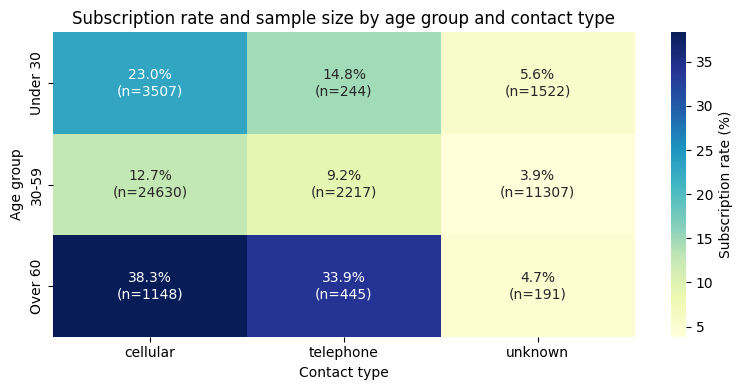

In [381]:
# @title Tasso di sottoscrizione per fascia d'età e mezzo di contatto
contact_age_counts = bank.pivot_table(
    index="age_category",
    columns="contact",
    values="y_numeric",
    aggfunc="size",
    observed=False
)

contact_age_success = bank.pivot_table(index="age_category", columns="contact",
    values="y_numeric", aggfunc="mean", observed=False) * 100

labels = (
    contact_age_success.round(1).astype(str)
    + "%\n(n="
    + contact_age_counts.astype(int).astype(str)
    + ")"
)

plt.figure(figsize=(8, 4))

sns.heatmap(
    contact_age_success,
    annot=labels,
    fmt="",
    cmap="YlGnBu",
    cbar_kws={"label": "Subscription rate (%)"}
)
labels = contact_age_success.round(1).astype(str) + "%\nN=" + contact_age_counts.astype(str)

plt.title("Subscription rate and sample size by age group and contact type")
plt.xlabel("Contact type")
plt.ylabel("Age group")
plt.tight_layout()
plt.show()

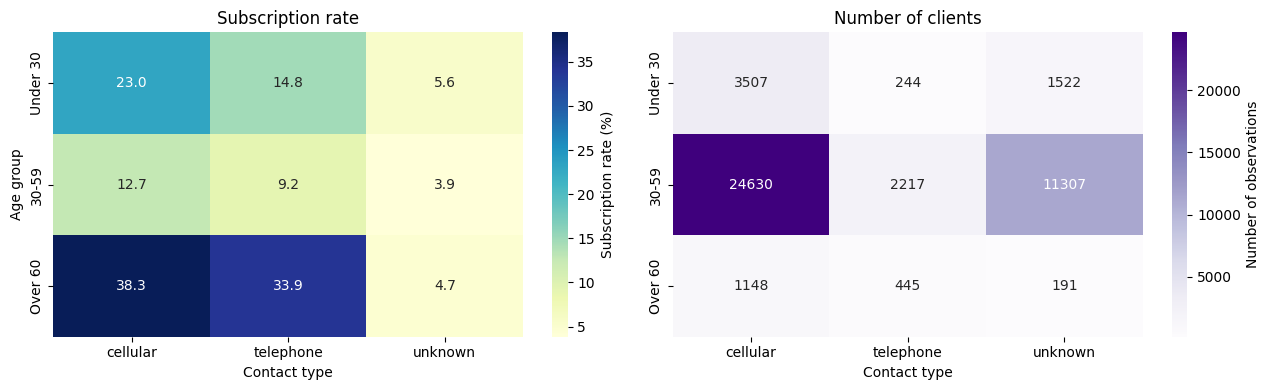

In [382]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(
    contact_age_success,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Subscription rate (%)"},
    ax=axes[0]
)

axes[0].set_title("Subscription rate")
axes[0].set_xlabel("Contact type")
axes[0].set_ylabel("Age group")

sns.heatmap(
    contact_age_counts,
    annot=True,
    fmt=".0f",
    cmap="Purples",
    cbar_kws={"label": "Number of observations"},
    ax=axes[1]
)

axes[1].set_title("Number of clients")
axes[1].set_xlabel("Contact type")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Dalla heatmap si ricavano degli interessanti punti:
* Le osservazioni con mezzo di contatto non registrato mostrano i tassi di sottoscrizione più bassi, intorno al 4-6%.
* Gli over 60 presentano tassi di sottoscrizione molto elevati sia con il cellulare (38,3%) sia con il telefono fisso (33,9%), circa tre volte superiori alla media dell'11.7%
* In tutte le fasce d'età, il cellulare è associato al tasso di sottoscrizione più elevato, con differenze di alcuni punti percentuali (da 3 a 8 circa) rispetto al telefono fisso.

Le differenze osservate non dipendono solo dal mezzo di contatto, bensì anche dalla numerosità (che varia molto tra le celle) e dall'età, dato che gli over 60 sono già più propensi alla sottoscrizione.


<Axes: xlabel='age', ylabel='smoothed_rate'>

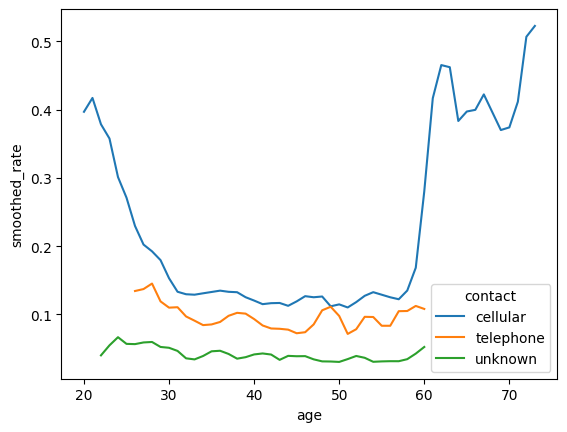

In [383]:
age_contact_detail = (
    bank.groupby(["age", "contact"])["y_numeric"]
    .agg(["mean", "count"])
    .reset_index()
)

age_contact_detail = age_contact_detail[
    age_contact_detail["count"] >= 30
].sort_values(["contact", "age"])

age_contact_detail["smoothed_rate"] = (
    age_contact_detail
    .groupby("contact")["mean"]
    .transform(
        lambda x: x.rolling(
            window=3, # media mobile di 3 anni
            center=True,
            min_periods=2
        ).mean()
    )
)

sns.lineplot(
    data=age_contact_detail,
    x="age",
    y="smoothed_rate",
    hue="contact"
)

La relazione tra età e probabilità di sottoscrizione non è lineare.

Per 'unknown' e 'telephone', il tasso è abbastanza stabile, mentre per 'cellular' assume una forma a U. Infatti, il tasso è più nettamente più elevato tra gli under 30 e soprattutto dopo i 58-60 anni (superando il 40%), laddove è più basso nella fascia centrale.

Questo è in linea con i risultati relativi all'occupazione, dove gli studenti e i pensionati sono risultati essere le categorie più propense a sottoscrivere il conto deposito. Tuttavia, si tratta anche di classi poco numerose nel nostro dataset.

Sorprende l'assenza di un picco intorno ai 60 anni per i contatti telephone, dato che la heatmap mostrava un tasso di sottoscrizione elevato tra gli over 60. Plausibilmente non si nota perché si tratta di pochi individui.

## Domanda 2.4

## Come varia il successo della campagna marketing a seconda del numero di contatti effettuati e secondo l'esito della campagna precedente?

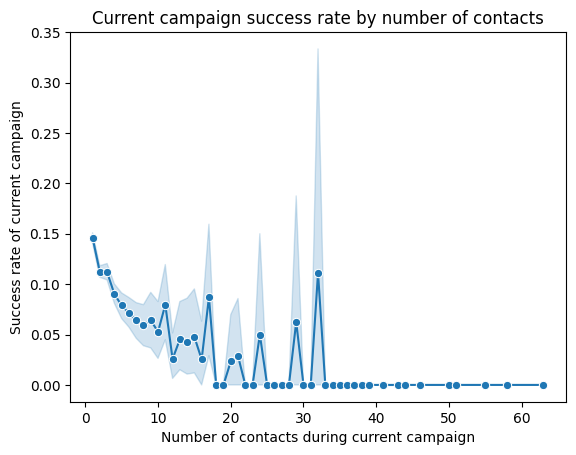

In [384]:
sns.lineplot(data=bank, x="campaign", y="y_numeric", marker="o", errorbar=("ci", 95))
#Media di y_numeric indica il success rate
plt.xlabel("Number of contacts during current campaign")
plt.ylabel("Success rate of current campaign")
plt.title("Current campaign success rate by number of contacts")
plt.show()

Il tasso di successo risulta massimo per i primi 1-3 contatti. Come già evidenziato dai dati in precedenza, possiamo vedere come un maggior numero di contatti nell'attuale campagna è associato a un successo decrescente. In particolare, oltre i 35 contatti circa, il tasso di successo è pari a 0.

Contatti ripetuti non aumentano dunque il tasso di successo. Al contrario, un numero elevato di contatti potrebbe indicare che si tratta di clienti più difficili da convincere.

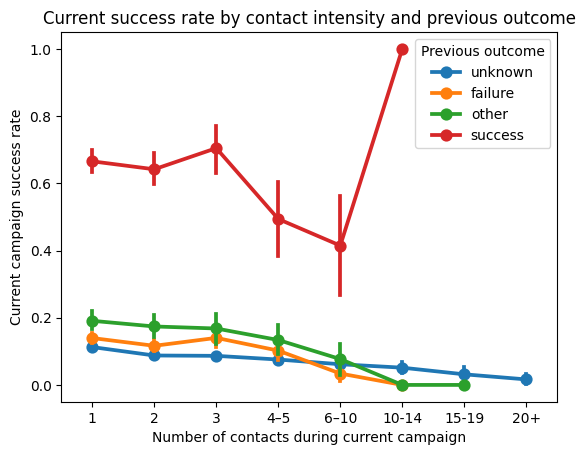

In [385]:
bank["campaign_group"] = pd.cut(
    bank["campaign"],
    bins=[0, 1, 2, 3, 5, 10, 15, 20, bank["campaign"].max()],
    labels=["1", "2", "3", "4–5", "6–10", "10-14", "15-19", "20+"]
)
# li unisco perché success aveva dei valori estremi e non era ben leggibile

sns.pointplot(data=bank, x="campaign_group", y="y_numeric", hue="poutcome", errorbar=("ci", 95))

plt.xlabel("Number of contacts during current campaign")
plt.ylabel("Current campaign success rate")
plt.title("Current success rate by contact intensity and previous outcome")
plt.legend(title = "Previous outcome")
plt.show()

Differenziando i clienti in base all'esito della precedente campagna marketing, notiamo delle notevoli differenze sia nell'efficacia dei contatti che nel tasso di successo.

I clienti che già hanno sottoscritto un conto deposito hanno tassi di successo molto più alti rispetto agli altri gruppi. Il precedente successo è un forte predittivo per il successo nella campagna attuale.

Invece, clienti con precedenti esiti negativi, diversi o ignoti mostrano un tasso di successo molto più basso. Inoltre, tra questi gruppi, il tasso di successo diminuisce con l'aumentare del numero dei contatti.

Nota: il tasso di successo tra i clienti che hanno già sottoscritto un conto deposito in precedenza arriva al 100% con un numero di contatti tra 10 e 14. Plausibilmente, si tratta di un campione di clienti molto ridotto.

Tutto sommato, sembra più efficace indirizzare gli sforzi verso clienti già 'affezionati' rispetto a insistere nel contattare coloro che hanno già risposto 'no' varie volte.

## Domanda 2.5

## Come varia la durata delle chiamate in base al periodo?

In [386]:
bank = bank.reset_index(drop=True) # per resettare l'indice

bank["month_index"] = (bank["month"] != bank["month"].shift()).cumsum()

Periodi con chiamate più lunghe hanno avuto tasso di successo più alto?



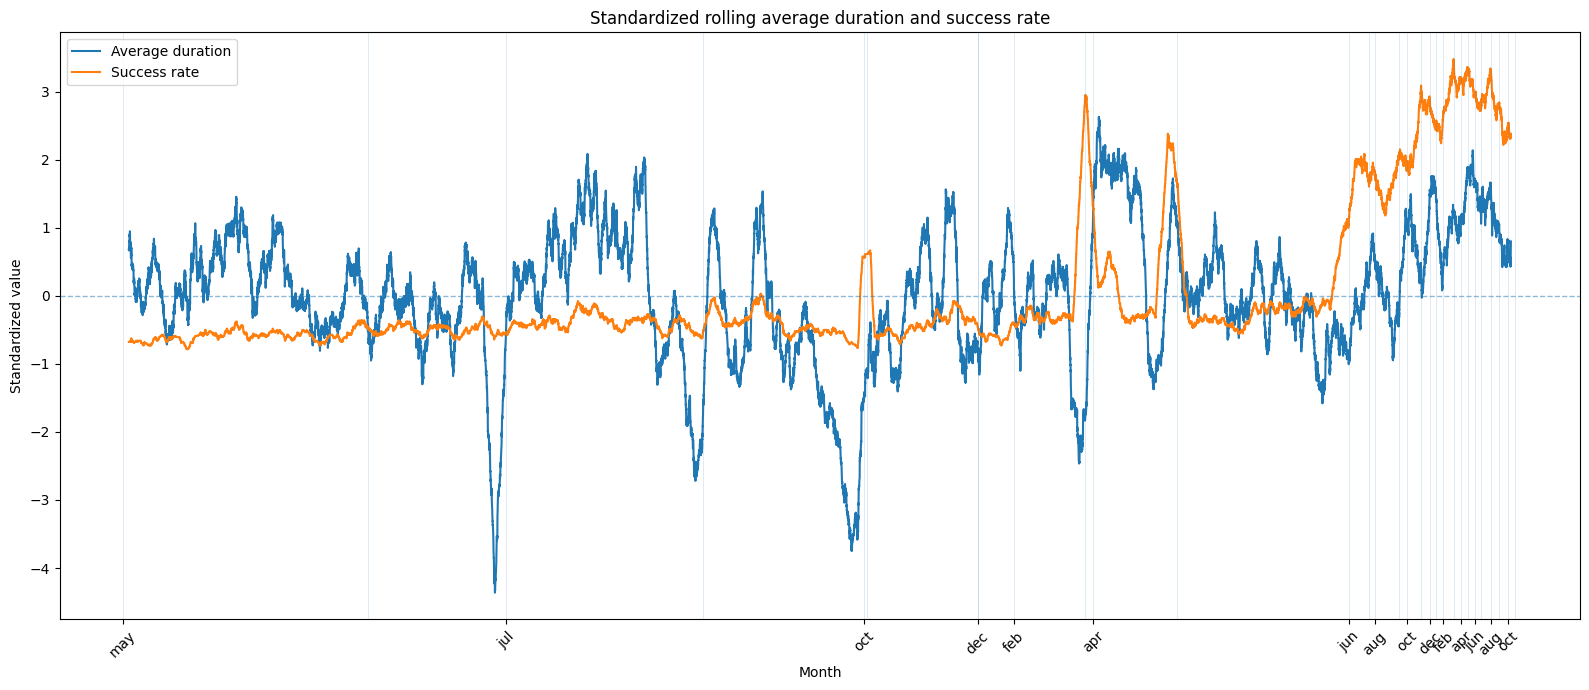

In [387]:
bank["rolling_duration"] = bank["duration"].rolling(window=400, center=True).mean()
bank["rolling_success"] = bank["y_numeric"].rolling(window=400, center=True).mean()

bank["duration_z"] = (bank["rolling_duration"] - bank["rolling_duration"].mean()) / bank["rolling_duration"].std()
bank["success_z"] = (bank["rolling_success"] - bank["rolling_success"].mean()) / bank["rolling_success"].std()

plt.figure(figsize=(16,7))

plt.plot(bank.index, bank["duration_z"], linewidth=1.5, label="Average duration")
plt.plot(bank.index, bank["success_z"], linewidth=1.5, label="Success rate")

month_starts = bank.groupby("month_index").head(1).index
month_labels = bank.loc[month_starts, "month"]

for x in month_starts:
    plt.axvline(x=x, linewidth=0.5, alpha=0.2)

plt.xticks(month_starts[::2], month_labels[::2], rotation=45)

plt.axhline(0, linestyle="--", linewidth=1, alpha=0.5)

plt.ylabel("Standardized value")
plt.xlabel("Month")
plt.title("Standardized rolling average duration and success rate")
plt.legend()
plt.tight_layout()
plt.show()

Per la maggior parte della campagna non emerge una chiara associazione tra durata media delle chiamate e tasso di successo. Una tendenza positiva comune si osserva soltanto nella fase finale, dove entrambe le serie registrano un incremento simultaneo.

Consideriamo invece come varia la durata delle chiamate guardando all'esito della campagna marketing.

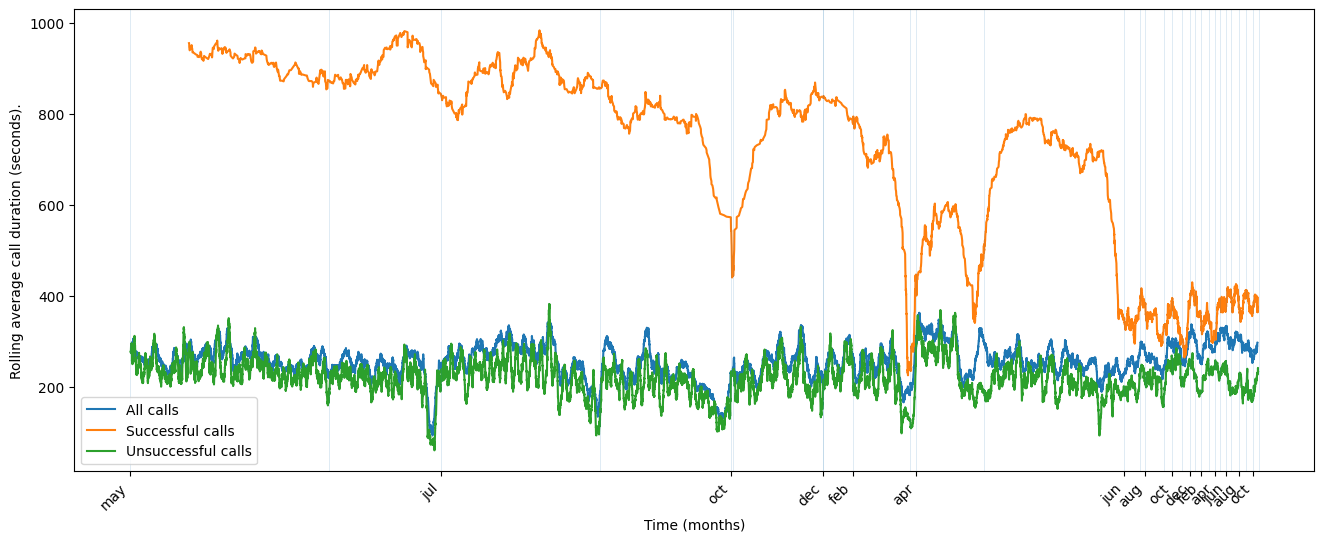

In [425]:

success = bank[bank["y_numeric"] == 1]
failure = bank[bank["y_numeric"] == 0]

plt.figure(figsize=(16,6))

plt.plot(bank["duration"].rolling(250, center=True).mean(),
         label="All calls")

plt.plot(success["duration"].rolling(100, center=True).mean(),
         label="Successful calls")

plt.plot(failure["duration"].rolling(100, center=True).mean(),
         label="Unsuccessful calls")

month_starts = bank.groupby("month_index").head(1).index
month_labels = bank.loc[month_starts, "month"].astype(str)

for x in month_starts:
    plt.axvline(x=x, linewidth=0.5, alpha=0.2)
# Display every second month label to reduce clutter
plt.xticks(month_starts[::2], month_labels[::2], rotation=45, ha='right') # Use month names and rotate labels

#plt.axhline(y=bank["duration"].mean(), color='red', linestyle='--', alpha=0.5) non ci sta molto

plt.ylabel("Rolling average call duration (seconds).")
plt.xlabel("Time (months)")
plt.legend()

Il grafico evidenzia che le chiamate che portano alla sottoscrizione del conto deposito sono mediamente più lunghe di quelle non di successo per tutto il periodo di osservazione. La durata media delle chiamate a esito positivo mostra inoltre una maggiore variabilità temporale, tendendo a decrescere verso la fine della campagna.
Le chiamate con esito negativo mantengono una durata più stabile ma su livelli nettamente inferiori.

La durata media si colloca tra i due andamenti, ma più vicina alle chiamate con esito negativo, che rappresentano difatti la maggioranza dei contatti.

In [389]:
monthly_contacts = bank.groupby("month_index")["y_numeric"].count()

comparison = pd.DataFrame({
    "period": ["First 12 months", "Following months"],
    "mean_monthly_contacts": [
        monthly_contacts.loc[1:12].mean(),
        monthly_contacts.loc[13:].mean()
    ],
    "total_contacts": [
        monthly_contacts.loc[1:12].sum(),
        monthly_contacts.loc[13:].sum()
    ]
})

print(comparison)

             period  mean_monthly_contacts  total_contacts
0   First 12 months            3312.666667           39752
1  Following months             303.277778            5459


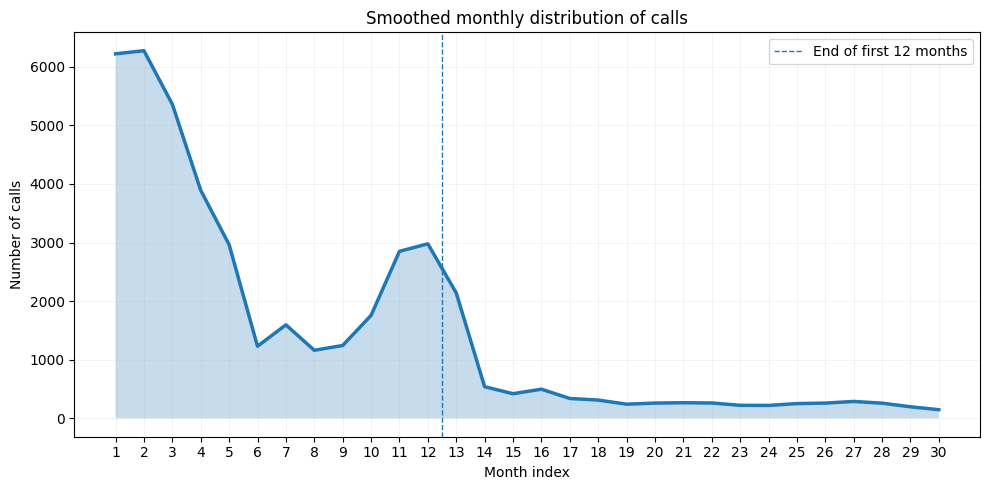

<Figure size 640x480 with 0 Axes>

In [426]:
monthly_calls = bank.groupby("month_index").size().reset_index(name="calls")

monthly_calls["calls_smooth"] = (
    monthly_calls["calls"]
    .rolling(window=3, center=True, min_periods=1)
    .mean()
)

plt.figure(figsize=(10,5))

plt.fill_between(
    monthly_calls["month_index"],
    monthly_calls["calls_smooth"],
    alpha=0.25
)

plt.plot(
    monthly_calls["month_index"],
    monthly_calls["calls_smooth"],
    linewidth=2.5
)

plt.axvline(12.5, linestyle="--", linewidth=1, label="End of first 12 months")

plt.xticks(monthly_calls["month_index"])
plt.xlabel("Month index")
plt.ylabel("Number of calls")
plt.title("Smoothed monthly distribution of calls")

plt.grid(alpha=0.2, linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Da questi dati si osserva che la distribuzione dei contatti effettuati è fortemente sbilanciata nel tempo. La maggior parte delle chiamate è concentrata nel primo anno, con una media di oltre 3.000 al mese, mentre nei mesi successivi il numero di osservazioni si riduce sensibilmente, attestandosi su poche centinaia di osservazioni al mese.

Pertanto, le stime relative all'ultima parte della campagna potrebbero essere influenzate dalla ridotta numerosità del campione, e quindi devono essere interpretate con maggior cautela.

In [391]:
### Create a mapping from month_index to month name
success_rate_by_month_index = bank.groupby("month_index")["y_numeric"].mean().mul(100).round(2)
month_index_to_name = bank[['month_index', 'month']].drop_duplicates().set_index('month_index')['month']

# Convert the success_rate_by_month_index Series to a DataFrame for easier merging
success_rate_df = success_rate_by_month_index.reset_index()
success_rate_df.columns = ['month_index', 'success_rate']

# Merge with the month names and sort by success rate
success_rate_with_names = success_rate_df.merge(month_index_to_name.rename('month'), left_on='month_index', right_index=True)
success_rate_with_names = success_rate_with_names.sort_values(by='success_rate', ascending=False)

success_rate_with_names.head(10)

,month_index,success_rate,month
4,5,61.25,oct
22,23,58.88,apr
23,24,57.26,may
21,22,56.16,mar
25,26,54.22,jul
20,21,52.69,feb
26,27,52.31,aug
17,18,49.49,nov
18,19,49.25,dec
27,28,49.16,sep


Infine, si nota quindi che i mesi in cui si evidenzia un maggior tasso di successo sono quelli in cui sono state effettuate meno chiamate.

I mesi con il tasso di sottoscrizione più elevato sono concentrati nella seconda parte della campagna, con valori superiori al 49% e un picco del 61,25% in ottobre. Tuttavia, si tratta di mesi con un numero di contatti molto inferiore rispetto alla fase iniziale. Dunque, percentuali così alte possono dipendere in buona parte dalle quantità ridotte di clienti chiamati in quei mesi.

# Fase 3

**Obiettivo**: confrontare modelli diversi.

**Requisiti** - almeno:

* 3 modelli diversi;

* di questi, se possibile, usate almeno 1 modello lineare (es. regressione) e 1
modello non lineare (es. k-NN, Random Forest).
Nota: a differenza del progetto di laboratorio, dovete svolgere voi le operazioni
richieste per preparare i dataset per la classificazione, ad esempio:

* train/test split

* conversione variabili categoriche in numeriche

Fase 4 VALUTAZIONE E INTERPRETAZIONE DEI RISULTATI

**Obiettivo**: valutazione critica dei risultati

**Requisiti** - per OGNI modello:
* accuracy;
* confusion matrix;
* precision;
* recall;
* f1-score.

Esempi di riflessioni:
* punti di forza;
* limiti;
* interpretabilità;
* tipo di errori;
* costo computazionale.

Altri possibili approfondimenti:
* feature importance (RF);
* coefficienti (regressione logistica)

## 3.1 Preparazione dell'ambiente e del dataset

In [392]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)


Ricarichiamo il dataset priginale

In [393]:
bank_mod = pd.read_csv("Bank_Marketing.csv", sep=";")
print (bank_mod)

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

In [394]:
bank_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Sono variabili categoriche ordinali:
* education
* month

Sono variabili categoriche nominali:
* job
* marital
* contact
* poutcome

Sono numeriche:
* age
* balance
* day
* duration
* campaign
* pdays
* previous

Sono dicotomiche yes/no:
* default
* housing
* loan
* y

Convertiamo le variabili yes/no in variabili numeriche 1/0.

In [395]:
bank_mod['y'] = bank_mod['y'].map({'no': 0, 'yes': 1})
bank_mod['default'] = bank_mod['default'].map({'no': 0, 'yes': 1})
bank_mod['housing'] = bank_mod['housing'].map({'no': 0, 'yes': 1})
bank_mod['loan'] = bank_mod['loan'].map({'no': 0, 'yes': 1})

Trasformiamo la variabile "month" in una variabile numerica cumulativa che assegna un valore progressivo a ciascun mese osservato. Così preserviamo la sequenza temporale che andrebbe altrimenti persa assegnando a ciascun mese un unico valore numerico anche quando si ripete.


In [396]:
bank_mod["month"] = (bank_mod["month"] != bank_mod["month"].shift()).cumsum()

Per 'education' applichiamo una codifica ordinale, assegnando valori numerici crescenti ai diversi livelli di istruzione, per mantenerne l'ordine.

Per le variabili categoriali nominali, usiamo il one-hot encoding, così creando una variabile binaria distinta per ogni categoria. Manteniamo tutte le categorie originali.

In [397]:
# Ordinale per 'education'
education_mapping = {
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}

bank_mod['education'] = bank_mod['education'].map(education_mapping)

# One-hot encoding for nominal categorical variables
bank_mod = pd.get_dummies(bank_mod, columns=['job', 'marital', 'contact', 'poutcome'], drop_first=False)

In [398]:
display(bank_mod.head())

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,3,0,2143,1,0,5,1,261,1,...,False,True,False,False,False,True,False,False,False,True
1,44,2,0,29,1,0,5,1,151,1,...,False,False,True,False,False,True,False,False,False,True
2,33,2,0,2,1,1,5,1,76,1,...,False,True,False,False,False,True,False,False,False,True
3,47,0,0,1506,1,0,5,1,92,1,...,False,True,False,False,False,True,False,False,False,True
4,33,0,0,1,0,0,5,1,198,1,...,False,False,True,False,False,True,False,False,False,True


Dividiamo i dati in training set e test set, assegnando il 60% delle osservazioni al training set, e il 40% al test set.

In [399]:
X = bank_mod.drop(columns=['y'])
y = bank_mod['y']

In [400]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (27126, 34)
Test set: (18085, 34)


In [401]:
X_test.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
5882,34,2,0,27,1,0,26,1,133,3,...,True,False,False,False,False,True,False,False,False,True
8533,35,3,0,2188,1,0,3,2,680,2,...,False,True,False,False,False,True,False,False,False,True
36474,35,2,0,847,1,0,11,12,85,2,...,False,False,True,True,False,False,False,False,False,True
34556,40,2,0,411,1,0,5,12,197,1,...,False,False,True,True,False,False,False,False,False,True
5975,33,3,0,403,1,0,26,1,114,2,...,False,True,False,False,False,True,False,False,False,True


In [402]:
print("Numero osservazioni:", X.shape[0])
print("Numero feature:", X.shape[1])

Numero osservazioni: 45211
Numero feature: 34


## 3.2 Regressione Logistica

Dato che la predizione dell'iscrizione di un cliente ad un conto deposito è un problema di classificazione binaria (iscritto/non iscritto), utilizziamo per primo il  modello della regressione logistica.

In [403]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
217,1.142047,-2.627048,-0.134784,-0.441507,-1.120290,-0.438221,-1.295748,-0.955547,0.579334,0.081514,...,-0.360053,0.814466,-0.629869,-1.356730,-0.261483,1.572230,-0.344648,-0.206655,-0.185355,0.469067
34160,1.236061,-0.067651,-0.134784,-0.445765,-1.120290,-0.438221,1.708917,0.635682,1.945124,0.081514,...,-0.360053,0.814466,-0.629869,-1.356730,3.824340,-0.636039,-0.344648,-0.206655,5.395048,-2.131894
34607,-1.020278,-0.067651,-0.134784,-0.354069,-1.120290,-0.438221,-1.295748,0.794805,-0.640670,0.081514,...,-0.360053,-1.227798,1.587631,-1.356730,3.824340,-0.636039,-0.344648,-0.206655,-0.185355,0.469067
447,0.860005,-2.627048,-0.134784,-0.473274,0.892626,-0.438221,-1.175561,-0.955547,-0.606141,-0.571319,...,-0.360053,0.814466,-0.629869,-1.356730,-0.261483,1.572230,-0.344648,-0.206655,-0.185355,0.469067
23636,1.800146,-0.067651,-0.134784,0.107685,-1.120290,-0.438221,1.468544,-0.478178,-0.748091,2.692845,...,-0.360053,0.814466,-0.629869,0.737066,-0.261483,-0.636039,-0.344648,-0.206655,-0.185355,0.469067


In [404]:
bank_model = LogisticRegression(max_iter=1000, random_state=42)
bank_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

15 secondi per il fitting

In [405]:
#from sklearn.linear_model import LogisticRegression
#log_reg = LogisticRegression(class_weight='balanced')

## 3.3 k-NN

**k-NN** è  un modello basato sulla vicinanza tra un punto del test e quelli del train (il parametro k indica il numero di vicini considerati).

* Anche questo modello risponde a problemi di classificazione.

* Richiede valori standardizzati, che abbiamo già reso tali nella fase precedente.

* Aggiustando il parametro k è possibile migliorare le performance del modello.

* Di contro è probabile che l'alto numero di dummies influisca negativamente su questa tipologia di modello.

Verifichiamo se **valori diversi di k** aumentano non solo l'accuratezza del modello, ma anche precisione, recall e soprattutto f1-score.

Partiamo con k = 5

In [406]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [407]:
pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, pred_knn)

print(f"Accuracy k-NN: {acc_knn:.3f}")

Accuracy k-NN: 0.893


In [408]:
pred_knn = knn.predict(X_test_scaled)

k_values = [1, 3, 5, 7, 9, 11, 21, 25, 29, 34, 45, 51, 80, 110]

results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred_knn = model.predict(X_test_scaled)
    random=42
    results.append({
            "k": k,
            "accuracy": accuracy_score(y_test, pred_knn),
            "precision_1": precision_score(y_test, pred_knn, pos_label=1),
            "recall_1": recall_score(y_test, pred_knn, pos_label=1),
            "f1_1": f1_score(y_test, pred_knn, pos_label=1),
        })

knn_results = pd.DataFrame(results)

knn_results = knn_results.sort_values(
    by='f1_1',
    ascending=False
)

display(knn_results)


,k,accuracy,precision_1,recall_1,f1_1
1,3,0.891125,0.552613,0.364839,0.439510
0,1,0.875809,0.465091,0.409263,0.435395
2,5,0.892784,0.575191,0.319943,0.411175
3,7,0.895881,0.608171,0.309546,0.410272
4,9,0.897208,0.627354,0.299149,0.405120
5,11,0.896986,0.633862,0.283081,0.391375
6,21,0.898148,0.673418,0.251418,0.366139
7,25,0.897871,0.677207,0.242911,0.357565
8,29,0.898037,0.685286,0.237713,0.352982
9,34,0.896655,0.684604,0.216446,0.328905


I valori sono ordinati in modo decrescente per f1-score:

l'accuracy resta sempre intorno all'89%, ma f1-score è molto più variabile.

**Scegliamo k = 3, come compromesso tra accuracy e f1-score**.

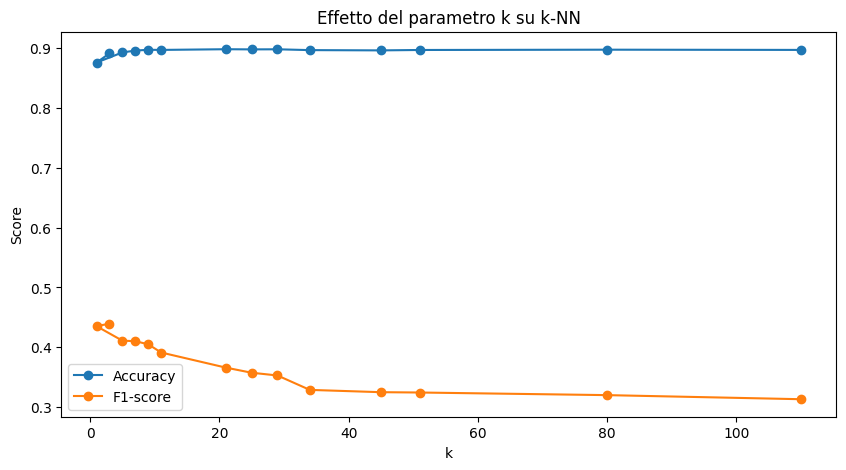

In [409]:
plt.figure(figsize=(10,5))
plt.plot(knn_results["k"], knn_results["accuracy"], marker="o", label="Accuracy")
plt.plot(knn_results["k"], knn_results["f1_1"], marker="o", label="F1-score")
plt.xlabel("k")
plt.ylabel("Score")
plt.title("Effetto del parametro k su k-NN")
plt.legend()
plt.show()

Quanto detto è confermato dal grafico:

- accuracy e f1-score variano diversamente, ma f1-score è decisamente minore per ogni k testato

- valori di k compresi fra 1 e 9 sono i preferibili per f1-score alto

- valori di k compresi fra 9 e 29 sono i preferibili per accuracy alta

**Testiamo il modello con k = 3**

In [410]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [411]:
pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, pred_knn)

print(f"Accuracy k-NN: {acc_knn:.3f}")

Accuracy k-NN: 0.891


## 3.4 Random Forest

Proseguiamo i nostri tentativi di classificazione con la Random Forest. Grazie alla classificazione di insieme e all'addestramento degli alberi su insiemi di dati diversi, i modelli prodotti con questo metodo sono spesso più robusti e meno sensibili al rumore.

Proviamo innanzitutto a identificare il numero ottimale di alberi e la soglia preferibile, ordinando i risultati in base a f1-score, in modo da preferire un bilanciamento tra precision e recall.

In [412]:
trees_values = [50, 100, 150, 200, 250, 300, 400, 500]
threshold_values = [0.5, 0.6, 0.7]

results = []

for tree in trees_values:
    model_rf = RandomForestClassifier(
        n_estimators=tree,
        max_depth=15,
        min_samples_leaf=3,
        min_samples_split=20,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )

    model_rf.fit(X_train, y_train)

    probs_rf = model_rf.predict_proba(X_test)[:, 1]

    for threshold in threshold_values:
        pred_rf = (probs_rf >= threshold).astype(int)

        results.append({
            "trees": tree,
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, pred_rf),
            "precision_1": precision_score(y_test, pred_rf, pos_label=1),
            "recall_1": recall_score(y_test, pred_rf, pos_label=1),
            "f1_1": f1_score(y_test, pred_rf, pos_label=1)
        })

rf_results = pd.DataFrame(results)

In [413]:
rf_results.sort_values("f1_1", ascending=False).round(3).head(5)

,trees,threshold,accuracy,precision_1,recall_1,f1_1
4,100,0.6,0.900,0.553,0.738,0.632
10,200,0.6,0.899,0.552,0.740,0.632
7,150,0.6,0.899,0.551,0.737,0.631
16,300,0.6,0.899,0.550,0.738,0.630
13,250,0.6,0.899,0.550,0.737,0.630


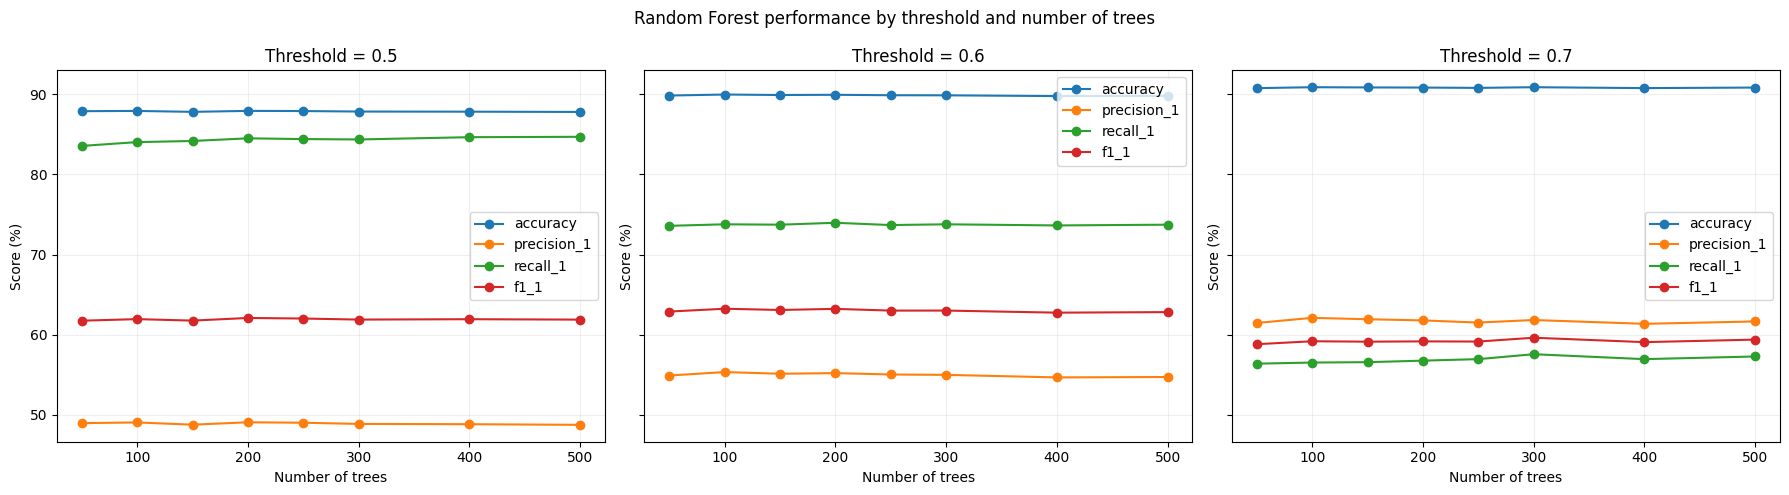

In [414]:
metrics = ["accuracy", "precision_1", "recall_1", "f1_1"]
thresholds = sorted(rf_results["threshold"].unique())

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, threshold in zip(axs, thresholds):

    data = rf_results[rf_results["threshold"] == threshold].sort_values("trees")

    for metric in metrics:
        ax.plot(data["trees"], data[metric] * 100,
            marker="o", label=metric)

    ax.set_title(f"Threshold = {threshold}")
    ax.set_xlabel("Number of trees")
    ax.set_ylabel("Score (%)")
    ax.grid(alpha=0.2)
    ax.legend()

plt.suptitle("Random Forest performance by threshold and number of trees")
plt.tight_layout()
plt.show()

Il grafico mostra che il numero di alberi indice molto poco sulle performance del modello. Infatti, dopo circa 100-200 alberi, precision, recall e F1-score, come anche l'accuratezza, rimangono stabili. Non vi è quindi un vantaggio nell'aumentare gli stimatori oltre 200, perché ciò aumenterebbe il costo computazionale senza portare a benefici significativi.

Più rilevanti sono le differenze che emergono dalla soglia di classificazione.

* soglia 0.5: recall massima (84-85%), ma precision bassa (~49%). L'accuracy è intorno all'88%

--> individua molti clienti effettivamente interessati, ma produce molti falsi positivi

* soglia 0.7: precision e recall sono più bilanciati, tra il 57-62%. Tuttavia, la recall cala molto.

--> maggiore selettività ma rischio di perdere per strada potenziali interessati

* soglia 0.6: ha un recall elevato (~74%) e precision sul 55%. Ha quindi valori intermedi rispetto alle altre due soglie.

--> buono nel riconoscere clienti veramente potenzialmente interessati, ma con meno falsi positivi rispetto a 0.5


Considerando che in una campagna marketing la priorità è captare quanti più clienti potenzialmente interessati, riteniamo che la soglia 0.6 rappresenti il miglior compromesso tra recall e precision della classe 1.

Alleniamo quindi il modello definitivo con 100 stimatori e soglia 0.6

In [415]:
rf_def = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=3,
    min_samples_split=20,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_def.fit(X_train, y_train)

probs = rf_def.predict_proba(X_test)[:, 1]
threshold = 0.6
pred_6 = (probs >= threshold).astype(int)

Il modello Random Forest è stato impostato tenendo conto dello sbilanciamento della variabile "y", dato che i clienti aderenti sono una minoranza del campione. Per questo motivo, abbiamo attribuito maggiore peso alla classe minoritaria con class_weight="balanced_subsample".


---


## 3.4.2 Feature Importance

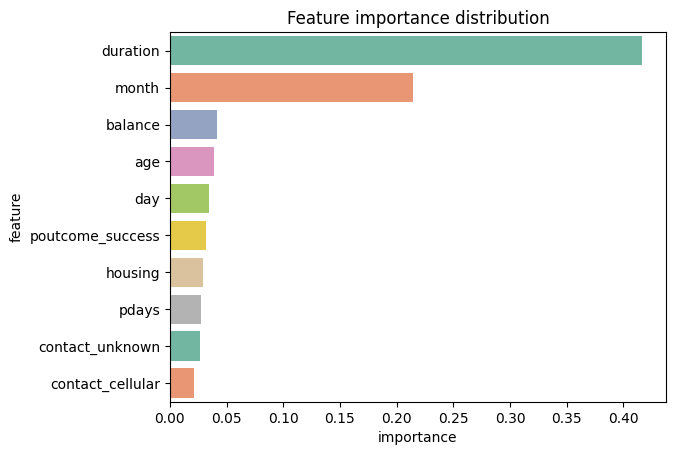

<Figure size 640x480 with 0 Axes>

In [427]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_def.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

sns.barplot(data=importance.head(10), y="feature", x="importance", hue="feature", palette='Set2')
plt.title("Feature importance distribution")
plt.show()

La feature importance indica che il potere predittivo risiede in poche variabili. La più rilevante è "duration" con un'importanza pari a 0,42, seguita da "month" con 0,21. Le altre variabili risultano meno rilevanti, con valori non superiori allo 0,05.

## Valutazione e confronto tra i modelli

###**Logistic Regression**

Calcoliamo ora i coefficienti di regressione, sulla base del modello bank_model.

In [417]:
# @title Coefficienti di regressione
coef = bank_model.coef_[0]
intercept = bank_model.intercept_

print("intercetta =",intercept)

regr = pd.DataFrame({
    "variabile": X.columns,
    "coefficiente": coef
})

regr_sorted = regr.reindex(regr['coefficiente'].abs().sort_values(ascending=False).index).reset_index(drop=True)

print("\nCoefficienti di regressione:")
display(regr_sorted)

intercetta = [-2.91072603]

Coefficienti di regressione:


,variabile,coefficiente
0,duration,1.133913
1,month,0.876081
2,housing,-0.276208
3,poutcome_success,0.264055
4,campaign,-0.142971
5,loan,-0.112993
6,poutcome_failure,-0.111002
7,education,0.098832
8,contact_unknown,-0.097264
9,contact_cellular,0.091601


Osserviamo che:

1. '**duration**' (1,13) ha il coefficiente col valore assoluto più alto: chiamate più lunghe aumentano la probabilità che il cliente si iscriva ad un conto deposito

2. segue '**month**' (0,87), ovvero il mese in cui si è stati contattati: il mese in cui il cliente è stato contattato influisce sulla probabilità che l'esito della chiamata sia positivo

3. '**housing**' (-0,27) : è la prima variabile a cui è associato un valore del coefficiente negativo:  il fatto di avere un mutuo scoraggia l'iscrizione ad un conto deposito

4. '**poutcome_success**' (0,26): se un cliente della banca è già stato contattato in passato e con successo, allora è più probabile che sia interessato ad un conto deposito

Ciascuno di questi esisti è confermato dalle nostre precedenti analisi, anche se la forza effettiva di queste relazioni è solo relativamente forte.


Accuracy: 0.91


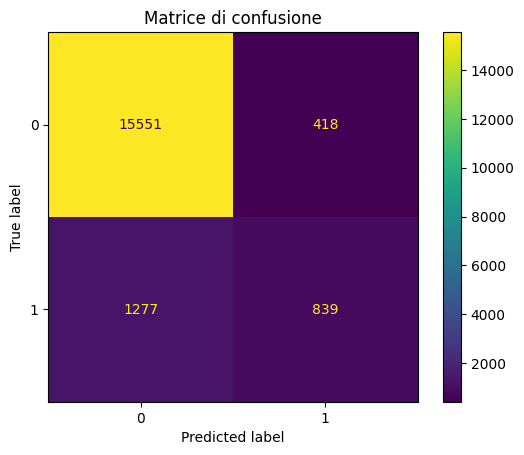

In [418]:
pred_log = bank_model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred_log)
cm = confusion_matrix(y_test, pred_log)

print(f"Accuracy: {acc:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot()
plt.title("Matrice di confusione")
plt.show()

Il modello è accurato: nel 90% dei casi le sue previsioni sono corrette.

In [419]:
print(classification_report(y_test, pred_log))
print("")

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     15969
           1       0.67      0.40      0.50      2116

    accuracy                           0.91     18085
   macro avg       0.80      0.69      0.72     18085
weighted avg       0.89      0.91      0.90     18085




Il modello:
* nel 92% dei casi è in grado di individuare correttamente se un caso è negativo
* non riesce ad individuare solo il 3% dei veri negativi

tuttavia:

* è meno preciso nel predire i positivi
* ha performance molto scarse se si tratta di predire i veri positivi (ne azzecca 4 su 10)

Queste lacune sono probabilmente dovute allo **squilibrio enorme fra le classi**, segnalato per'altro dal valore support (i casi nella classe 1 sono appena il 13% dei casi nella classe 0).


**Concludiamo** che:

* il modello è discreto, considerando il forte sbilanciamento fra le classi (solo l'11% dei clienti nel dataset hanno aperto un conto deposito)

* è poco affidabile se si tratta di predire i clienti disposti ad aprire un conto deposito (classe 1): indovina il 67% dei positivi e il 40% dei casi positivi reali.

###**k-NN**

Accuracy: 0.89


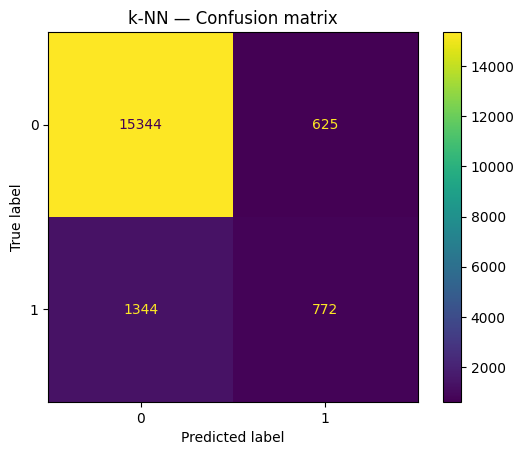

In [420]:
cm_knn = confusion_matrix(y_test, pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['0', '1']
)


print(f"Accuracy: {acc_knn:.2f}")

disp.plot()
plt.title("k-NN — Confusion matrix")
plt.show()

In [421]:
print(classification_report(y_test, pred_knn))
print("")

              precision    recall  f1-score   support

           0       0.92      0.96      0.94     15969
           1       0.55      0.36      0.44      2116

    accuracy                           0.89     18085
   macro avg       0.74      0.66      0.69     18085
weighted avg       0.88      0.89      0.88     18085




L'89,1% dei casi sono previsti correttamente.

Notiamo che rispetto al modello precedente

* la recall per la classe 1 è ancora più bassa: sbaglia 7 casi su 10 veri positivi

* tuttavia f1-score resta molto simile, con una diminuzione del 6% per la classe 1


Ricalchiamo quanto possa influire sfavorevolmente sulla performance del modello lo **squilibrio fra le classi**.


**Concludiamo che**: il modello k-NN è sconsigliabile per questo dataset, poiché è portato a sbagliare la predizione dei veri positivi, cioè i casi che più interessano alla banca.

>Il modello non riesce quasi a predire correttamente i clienti che apriranno effettivamente un conto deposito.



### **Random Forest**

Accuracy 89.96 %


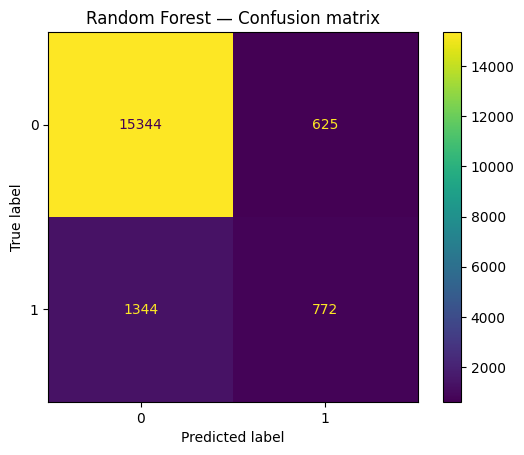

In [422]:
cm_rf = confusion_matrix(y_test, pred_6)
ConfusionMatrixDisplay(confusion_matrix=cm_rf)

print("Accuracy", round(accuracy_score(y_test, pred_6)*100, 2), "%")
disp.plot()
plt.title("Random Forest — Confusion matrix")
plt.show()

In [423]:
print("Threshold: 0.6")
print(classification_report(y_test, pred_6))
print("")

Threshold: 0.6
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     15969
           1       0.55      0.74      0.63      2116

    accuracy                           0.90     18085
   macro avg       0.76      0.83      0.79     18085
weighted avg       0.92      0.90      0.91     18085




L'accuracy complessiva è quasi del 90%. Tuttavia, dato che nel nostro dataset la classe 0 è molto più numerosa della classe 1, le metriche relative alla classe 1 sono più informative.

Per la classe positiva, il modello ottiene una recall pari a 74%. Quindi identifica i 3/4 dei clienti che effettivamente sottoscrivono il conto deposito. Con una precision del 55%, tra i clienti classificati dal modello come potenziali aderenti, poco più di metà aderisce veramente.

Complessivamente, il modello non è molto selettivo e produce una quota sostanziosa di falsi positivi, però riesce a intereccettare molti clienti interessati.


# Conclusioni

In [424]:
confronto = pd.DataFrame({
    "Model": ["Logistic Regression", "k-NN", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_6)
    ],
    "Precision": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_6)
    ],
    "Recall": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_6)
    ],
    "F1-score": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_6)
    ]
}).set_index("Model")

print('confronto fra modelli (valori classe 1)')
display(confronto)

confronto fra modelli (valori classe 1)


,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.906276,0.667462,0.396503,0.497480
k-NN,0.891125,0.552613,0.364839,0.439510
Random Forest,0.899641,0.553350,0.737713,0.632368


Concludiamo che il modello che meglio predice se un cliente sottoscriverà un conto deposito è Random Forest.

Resta il fatto che il modello non eccelle, ma è capace di gestire un dataset fortemente sbilanciato a favore dei clienti non iscritti, dimostrando un'ottima capacità predittiva per i clienti realmente iscritti.
